In [1]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA 
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install imblearn
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install xgboost
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multitest import multipletests
from scipy.stats import t as tdist
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.metrics import r2_score, make_scorer
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from scipy.stats import t as tdist
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.ensemble import  GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict




[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Loading the genetic dataset

In [2]:
# Read the genetic data
genetic_data = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\GeneMarkers-95 varieties 1.csv")

genetic_data.info
genetic_data.head(10)

,taglo_id,ATLANTIC_124776,ESCORT_159228,ARGOS_120931,ALTURAS_329540,ELMUNDO_835520,NADINE_241950,VIOLETQUEEN_3345402,DEODARA_513721,MEMPHIS_2279529,...,DIAMANT_153502,INNOVATOR_234757,TRIPLE7_3347283,SPUNTA_283648,ANTI_118190,CARRERA_142554,FORTUS_3279866,SMART_1883446,SALINERO_253609,FABULA_171173
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,17,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,39,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,48,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,49,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,54,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


# Checking the missing values

In [3]:
genetic_data.isnull().sum()

taglo_id           0
ATLANTIC_124776    0
ESCORT_159228      0
ARGOS_120931       0
ALTURAS_329540     0
                  ..
CARRERA_142554     0
FORTUS_3279866     0
SMART_1883446      0
SALINERO_253609    0
FABULA_171173      0
Length: 95, dtype: int64

In [4]:
# Clean column names
genetic_columns_clean = [c.strip().upper().replace(" ", "").replace(".", "") for c in genetic_data.columns]

# Assign cleaned names back to DataFrame
genetic_data.columns = genetic_columns_clean
print(genetic_data.columns)

Index(['TAGLO_ID', 'ATLANTIC_124776', 'ESCORT_159228', 'ARGOS_120931',
       'ALTURAS_329540', 'ELMUNDO_835520', 'NADINE_241950',
       'VIOLETQUEEN_3345402', 'DEODARA_513721', 'MEMPHIS_2279529',
       'AGRIA_125336', 'PAYETTERUSSET_4617676', 'IVORYRUSSET_1360551',
       'SABABA_4959615', 'CECILE_147140', 'FRISIA_163592', 'CARDYMA_3345873',
       'RICKEYRUSSET_4640884', 'ANIVIA_4446779', 'AVARNA_1630052',
       'DONALD_158741', 'JAERLA_231308', 'ARIZONA_3056017',
       'SARPOMIRA_1629377', 'MARILYN_1632173', 'DESIREE_139717',
       'MUSE_6159099', 'ADORA_123802', 'TAURUS_1883495', 'BERBER_121293',
       'RANGERRUSSET_265488', 'BINTJE_126680', 'FENWAYRED_4055844',
       'KONDOR_248484', 'SAGITTA_1459411', 'CLEARWATERR_2721777',
       'NICOLA_248062', 'TETONRUSSET_3029162', 'FESTIEN_172619',
       'HANSA_180216', 'PEEWEERUSSET_3347291', 'PRINCEOFORANGE_416115',
       'SUPERIOR_1477892', 'VANGOGH_294181', 'CHALLENGER_1883438',
       'JENNIFER_3221728', 'PARELLA_2983716', 'CH

# loading the flavor-aroma dataset which already derived.

In [5]:
merged_flavor_aroma= pd.read_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_plus_predicted_flavors_94.csv')
merged_flavor_aroma
merged_flavor_aroma.columns
merged_flavor_aroma.shape

(94, 47)

# Merge genetic data with aroma_flavor dataset for further analysis

In [ ]:
# preparing the data
def to_numeric(df):
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def norm_key(s):
    s = (str(s).upper().replace(".", "").replace(" ", ""))
    s = re.sub(r'\bR\b', '', s)
    s = re.sub(r'RUSSET', '', s)
    return s.split("_")[0]

# Detecting the SNP marker column 
mrk_col = "TAGLO_ID" if "TAGLO_ID" in genetic_data.columns else genetic_data.columns[0]

#  Clean genetics 
G = genetic_data.dropna(subset=[mrk_col]) \
                .drop_duplicates(subset=[mrk_col]) \
                .set_index(mrk_col)

G = to_numeric(G)         
gd = G.T                  # varieties × markers
gd.index.name = "Variety_raw"
gd.index = gd.index.map(norm_key)

# Collapse duplicates if multiple rows per variety
gd = gd.groupby(gd.index, observed=True).mean()
gd.columns = ["GEN__" + str(c) for c in gd.columns]
print("Genetic table after reshape:", gd.shape)

# copy of  Aroma + Flavor 
af = merged_flavor_aroma.copy()
assert "Variety" in af.columns, "merged_flavor_aroma must have a 'Variety' column"
af["__key__"] = af["Variety"].map(norm_key)
af = af.set_index("__key__")

#proviiding the  Aroma names 
aroma_names = [
    '1-Nonanol (Floral, waxy)',
    '2,3-Butanedione (Butter, creamy, sweet)',
    'Benzaldehyde (Almond, cherry, fruity)',
    'Butanal, 3-methyl- (Fruity, malty, chocolate)',
    'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
    'Decanal (Citrus, floral)',
    'Dimethyl trisulfide (Garlic, onion, sulfurous)',
    'Furfural (Sweet, almond, caramel)',
    'Hexanal (Green, grassy)',
    'Hexanoic acid (Fatty, cheesy, sweaty)',
    'Methional (Cooked potato, sulfurous)',
    'Octanal (Citrus, fruity)',
    'Pentanal (Green, fatty, pungent)',
]

col_str = af.columns.astype(str)

# Keeping only the calibrated flavor predictions
flavor_cols = [c for c in col_str if c.endswith("__pred_cal")]

# Keep only whitelist aroma compounds that exist
aroma_cols = [c for c in aroma_names if c in col_str]

# Clean aroma 
A = to_numeric(af[aroma_cols]).dropna(axis=1, how="all")
A = A.loc[:, A.std(ddof=0).fillna(0) > 0]   # drop constant cols

# Flavors
F = to_numeric(af[flavor_cols])

print(f"# aroma candidates (usable): {A.shape[1]}")
print(f"# predicted flavor cols (cal only): {F.shape[1]}")
print("Sample aroma cols:", list(A.columns[:8]))

# Merge with genetics
gk = gd.copy()
gk.index.name = "Variety"

merged_all = gk.join(pd.concat([A, F], axis=1), how="inner")
print("Merged shape (varieties × [SNPs + aroma + flavor]):", merged_all.shape)


Genetic table after reshape: (94, 262434)
# aroma candidates (usable): 13
# predicted flavor cols (cal only): 11
Sample aroma cols: ['1-Nonanol (Floral, waxy)', '2,3-Butanedione (Butter, creamy, sweet)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Dimethyl trisulfide (Garlic, onion, sulfurous)', 'Furfural (Sweet, almond, caramel)']
Merged shape (varieties × [SNPs + aroma + flavor]): (94, 262458)


# Prepare aroma matrix and PCs from genotype 

In [7]:
# Prepare aroma matrix and PCs from genotype 
OUTDIR = Path("prep_outputs"); OUTDIR.mkdir(parents=True, exist_ok=True)

df = merged_all.copy()
df.index.name = "Variety"

# Aroma intensity columns present
aroma_cols = [c for c in aroma_names if c in df.columns]
if not aroma_cols:
    raise RuntimeError("No aroma columns from AROMA_NAMES found in merged_all.")
print(f"[ok] Found {len(aroma_cols)} aroma columns.")

# Log1p transform for modeling/ANOVA
for c in aroma_cols:
    df[c + "__log1p"] = np.log1p(df[c].astype(float).clip(lower=0))

# SNP columns
SNP_PREFIX = "GEN__" 
snp_cols = [c for c in df.columns if c.startswith(SNP_PREFIX)]
print(f"[info] SNP columns: {len(snp_cols)}")

    # choose up to MAX_SNP_PCA SNPs with least missingness & higher variance
MAX_SNP_PCA = 5000
miss = df[snp_cols].isna().mean(0)                    # missing rate per SNP
var  = df[snp_cols].var(0, skipna=True)               # variance (NaN-safe)
score = (1.0 - miss).rank(ascending=False) + var.rank(ascending=False)
pick = score.sort_values(ascending=False).index[:min(MAX_SNP_PCA, len(snp_cols))]

    # impute mode genotype (most_frequent), cast to float32 to save memory
G = df[pick].astype('float32')
imputer = SimpleImputer(strategy="most_frequent")
G_imp = imputer.fit_transform(G)   # shape: (n_samples, p)

# IncrementalPCA 
ipca = IncrementalPCA(n_components=5, batch_size=512)
PCs = ipca.fit_transform(G_imp)
evr = getattr(ipca, "explained_variance_ratio_", None)

 
for i in range(5):
    df[f"PC{i+1}"] = PCs[:, i]

if evr is not None:
    cum = evr.cumsum()
    print(f"[ok] Added PCs: PC1–PC5 | EVR={np.round(evr,3)} | cumulative={np.round(cum,3)}")
else:
    print("[ok] Added PCs: PC1–PC5")

# Stash prepared DF
df.to_csv("C:/Users/fatemehm/OneDrive - Royal HZPC Group\Desktop/internship/bio_rep1/merged_prepared.csv")



<>:50: SyntaxWarning: invalid escape sequence '\D'
<>:50: SyntaxWarning: invalid escape sequence '\D'
C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9144\745414124.py:50: SyntaxWarning: invalid escape sequence '\D'
  df.to_csv("C:/Users/fatemehm/OneDrive - Royal HZPC Group\Desktop/internship/bio_rep1/merged_prepared.csv")


[ok] Found 13 aroma columns.
[info] SNP columns: 262434
[ok] Added PCs: PC1–PC5 | EVR=[0.457 0.254 0.084 0.049 0.014] | cumulative=[0.457 0.711 0.795 0.844 0.859]


# HCA (Ward, Euclidean) on aroma profiles (EDA)

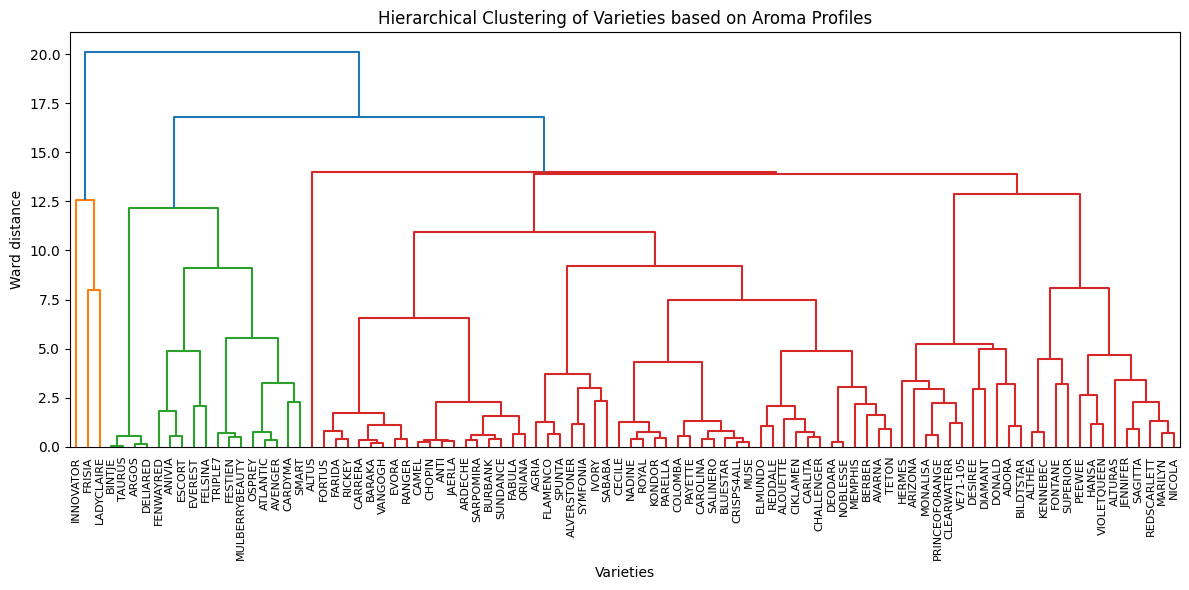

In [8]:

merged_prepared = df.copy()

# use the same aroma list
AROMA_COLS = [c for c in aroma_names if c in merged_prepared.columns]
assert AROMA_COLS, "No aroma columns found in merged_prepared.csv."

X = merged_prepared[AROMA_COLS].copy().fillna(0.0)

# scale columns so compounds contribute equally
Xz = pd.DataFrame(StandardScaler().fit_transform(X.values),
                  index=X.index, columns=AROMA_COLS)

Z = linkage(Xz, method="ward", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=X.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering of Varieties based on Aroma Profiles")
plt.xlabel("Varieties"); plt.ylabel("Ward distance")
plt.tight_layout(); plt.show()


In [9]:

# Evaluate k
k_range = range(2, 11)
sil, ch, db = [], [], []
D = pdist(Xz, metric="euclidean")
for k in k_range:
    labs = fcluster(Z, k, criterion="maxclust")
    sil.append(silhouette_score(Xz, labs))
    ch.append(calinski_harabasz_score(Xz, labs))
    db.append(davies_bouldin_score(Xz, labs))

# Choose best k by max silhouette 
best_k = k_range[int(np.argmax(sil))]
print("k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin")
for k, si, c, d in zip(k_range, sil, ch, db):
    print(f"{k:2d} |   {si:8.3f}   |     {c:10.1f}     |     {d:6.3f}")
print(f"\nSelected k = {best_k} (by silhouette)")

# Final labels
clusters = fcluster(Z, best_k, criterion="maxclust")
merged_prepared[f"AromaCluster_k{best_k}"] = clusters
merged_prepared[[f"AromaCluster_k{best_k}"]].to_csv(OUTDIR / f"aroma_clusters_k{best_k}.csv")
print("\nCluster sizes:\n", pd.Series(clusters, index=merged_prepared.index).value_counts().sort_index())


k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin
 2 |      0.584   |           18.2     |      1.067
 3 |      0.235   |           17.8     |      1.503
 4 |      0.247   |           17.0     |      1.226
 5 |      0.210   |           17.5     |      1.426
 6 |      0.247   |           18.2     |      1.201
 7 |      0.249   |           19.4     |      1.048
 8 |      0.274   |           21.2     |      0.986
 9 |      0.242   |           22.9     |      1.028
10 |      0.265   |           23.7     |      0.992

Selected k = 2 (by silhouette)

Cluster sizes:
 1     3
2    91
Name: count, dtype: int64


 the clusters are imbalance it probably beacuse of outiers so we will check the outliers.

# Dendrogram with Outliers Highlighted

Outlier varieties: ['FRISIA', 'INNOVATOR', 'LADYCLAIRE']


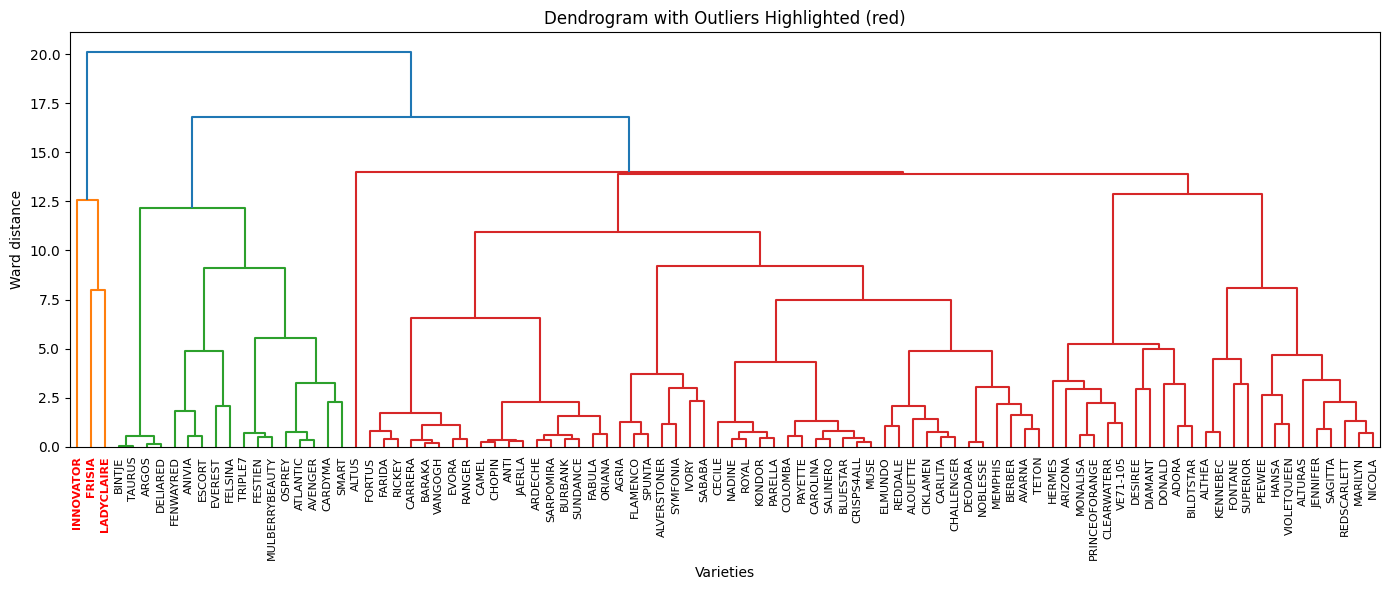

In [10]:


# Find outlier cluster 
cluster_sizes = pd.Series(clusters).value_counts()
outlier_cluster = cluster_sizes.idxmin()
outliers = X.index[clusters == outlier_cluster].tolist()
print("Outlier varieties:", outliers)

# Plot dendrogram, color outliers red
plt.figure(figsize=(14, 6))
ddata = dendrogram(Z, labels=X.index.tolist(),
                   leaf_rotation=90, leaf_font_size=8)

# Highlight outliers
ax = plt.gca()
for lbl in ax.get_xmajorticklabels():
    if lbl.get_text() in outliers:
        lbl.set_color("red")
        lbl.set_fontweight("bold")

plt.title("Dendrogram with Outliers Highlighted (red)")
plt.xlabel("Varieties")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()


AS can be seen the outliers has been shown in red. we have three outlier.

In [11]:
# Remove outlier varieties identified by HCA 
OUTLIERS = ["FRISIA", "INNOVATOR", "LADYCLAIRE"]

print(f"[info] Original dataset size: {merged_prepared.shape}")
merged_clean = merged_prepared.drop(index=OUTLIERS, errors="ignore")
print(f"[ok] Removed outliers: {OUTLIERS}")
print(f"[info] Cleaned dataset size: {merged_clean.shape}")

# Save a cleaned copy for consistency
OUTDIR = Path("prep_outputs"); OUTDIR.mkdir(exist_ok=True)
merged_clean.to_csv(OUTDIR / "merged_clean.csv")
print(f"[ok] Saved: {OUTDIR/'merged_clean.csv'}")


[info] Original dataset size: (94, 262477)
[ok] Removed outliers: ['FRISIA', 'INNOVATOR', 'LADYCLAIRE']
[info] Cleaned dataset size: (91, 262477)
[ok] Saved: prep_outputs\merged_clean.csv


# HCA on clean dataset

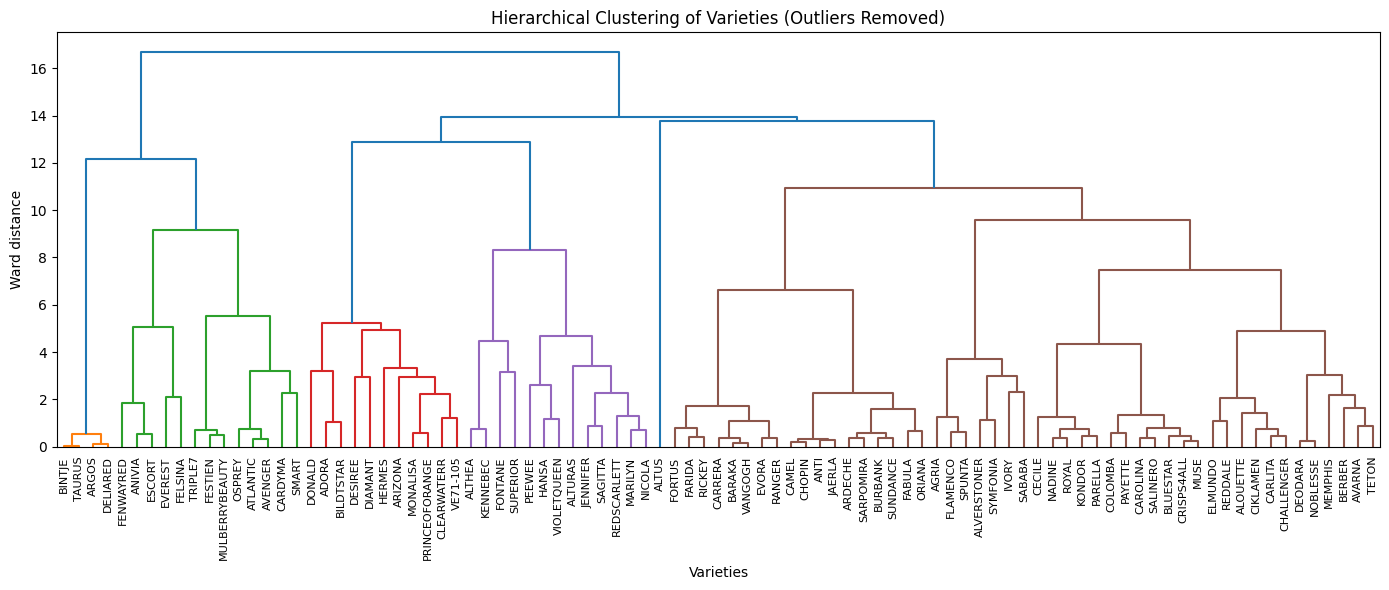

In [12]:

AROMA_COLS = [c for c in aroma_names if c in merged_clean.columns]
assert AROMA_COLS, "No aroma columns found."

X = merged_clean[AROMA_COLS].copy().fillna(0.0)

# Standardize so each aroma contributes equally
Xz = pd.DataFrame(StandardScaler().fit_transform(X), 
                  index=X.index, columns=AROMA_COLS)

Z = linkage(Xz, method="ward", metric="euclidean")

plt.figure(figsize=(14, 6))
dendrogram(Z, labels=X.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering of Varieties (Outliers Removed)")
plt.xlabel("Varieties"); plt.ylabel("Ward distance")
plt.tight_layout(); plt.show()


 After removing the ouliers we have 5 stable culsters

# SNP–Aroma Association via PCA + PLSR

In [13]:

# SNP PCA

# Extract SNP columns from merged_clean
X = merged_clean[[c for c in merged_clean.columns if c.startswith("GEN__")]].astype(float)

# PCA on SNPs (reduce dimensionality)
pca_snp = PCA(n_components=min(30, X.shape[0]), random_state=42)
X_pca = pca_snp.fit_transform(X)

print("X shape (raw SNPs):", X.shape)
print("X_pca shape (reduced SNP PCs):", X_pca.shape)
print("Explained variance (SNP PCs):", pca_snp.explained_variance_ratio_.sum())


#  Aroma PCA

aroma_cols = [c for c in aroma_names if c in merged_clean.columns]
aroma_data = merged_clean[aroma_cols].astype(float).fillna(0)

# Log-transform
aroma_log = np.log1p(aroma_data.clip(lower=0))

# PCA on aroma traits
pca_aroma = PCA(n_components=3, random_state=42)
aroma_pc_scores = pca_aroma.fit_transform(aroma_log)

aroma_pcs = pd.DataFrame(
    aroma_pc_scores,
    index=merged_clean.index,
    columns=["Aroma_PC1", "Aroma_PC2", "Aroma_PC3"]
)

print("Explained variance (aroma PCs):", pca_aroma.explained_variance_ratio_.sum())


# PLSR 

Y = aroma_pcs[["Aroma_PC1", "Aroma_PC2", "Aroma_PC3"]]
pls = PLSRegression(n_components=2)
cv = KFold(n_splits=10, shuffle=True, random_state=42)


# Evaluate per-PC R²

print("\nPer-PC evaluation:")
for col in Y.columns:
    y = Y[col].values
    scores = cross_val_score(pls, X_pca, y, cv=10, scoring="r2", n_jobs=-1)
    print(f"{col} (PLSR): R² = {scores.mean():.3f} ± {scores.std():.3f}")


#  Evaluate multivariate R² (all PCs together)

def multivariate_r2(y_true, y_pred):
    r2s = []
    for i in range(y_true.shape[1]):
        if np.std(y_true[:, i]) > 1e-6:
            r2s.append(r2_score(y_true[:, i], y_pred[:, i]))
        else:
            r2s.append(0.0)  # treat constant targets as 0 explanatory power
    return np.mean(r2s)
merged_clean.shape

X shape (raw SNPs): (91, 262434)
X_pca shape (reduced SNP PCs): (91, 30)
Explained variance (SNP PCs): 0.612908565760814
Explained variance (aroma PCs): 0.663483148335798

Per-PC evaluation:
Aroma_PC1 (PLSR): R² = -0.940 ± 0.753
Aroma_PC2 (PLSR): R² = -1.113 ± 0.724
Aroma_PC3 (PLSR): R² = -0.873 ± 0.631


(91, 262477)

# Identification of Candidate SNP Markers Associated with Aroma/Flavor Variation via PCA-PLSR

In [14]:
# X = merged_clean[[c for c in merged_clean.columns if c.startswith("GEN__")]].astype(float)
X_pca = pca_snp.fit_transform(X)

# Fit PLSR on full dataset
pls.fit(X_pca, Y)

# Get SNP loadings (back-project PCA -> SNP space)
snp_loadings = pca_snp.components_.T @ pls.x_weights_

snp_influence = pd.DataFrame(
    snp_loadings,
    index=X.columns,
    columns=["PLS1", "PLS2"]
)

# Rank SNPs by absolute contribution to PLS1 (or whichever is most predictive)
top_snps = snp_influence["PLS1"].abs().sort_values(ascending=False).head(50)
print(top_snps)
len(top_snps)

GEN__514961    0.018025
GEN__514837    0.017746
GEN__513775    0.016606
GEN__515147    0.016228
GEN__513979    0.016159
GEN__513659    0.016159
GEN__514392    0.016159
GEN__514831    0.016159
GEN__513428    0.016123
GEN__514447    0.015820
GEN__514491    0.015820
GEN__514585    0.015820
GEN__515113    0.015781
GEN__513832    0.015779
GEN__508126    0.015727
GEN__515239    0.015727
GEN__514345    0.015695
GEN__513617    0.015677
GEN__513465    0.015677
GEN__513306    0.015677
GEN__513591    0.015677
GEN__513508    0.015677
GEN__514231    0.015619
GEN__515036    0.015569
GEN__513694    0.015439
GEN__514715    0.015439
GEN__514672    0.015355
GEN__514895    0.015314
GEN__513160    0.015309
GEN__515282    0.015280
GEN__508246    0.015279
GEN__509613    0.015270
GEN__515516    0.015247
GEN__515515    0.015247
GEN__515399    0.015155
GEN__515566    0.015025
GEN__513023    0.014994
GEN__513074    0.014994
GEN__512942    0.014994
GEN__513351    0.014937
GEN__512771    0.014918
GEN__512608    0

50

# Visualize SNP contributions (Manhattan-style plot but with PLS loadings)

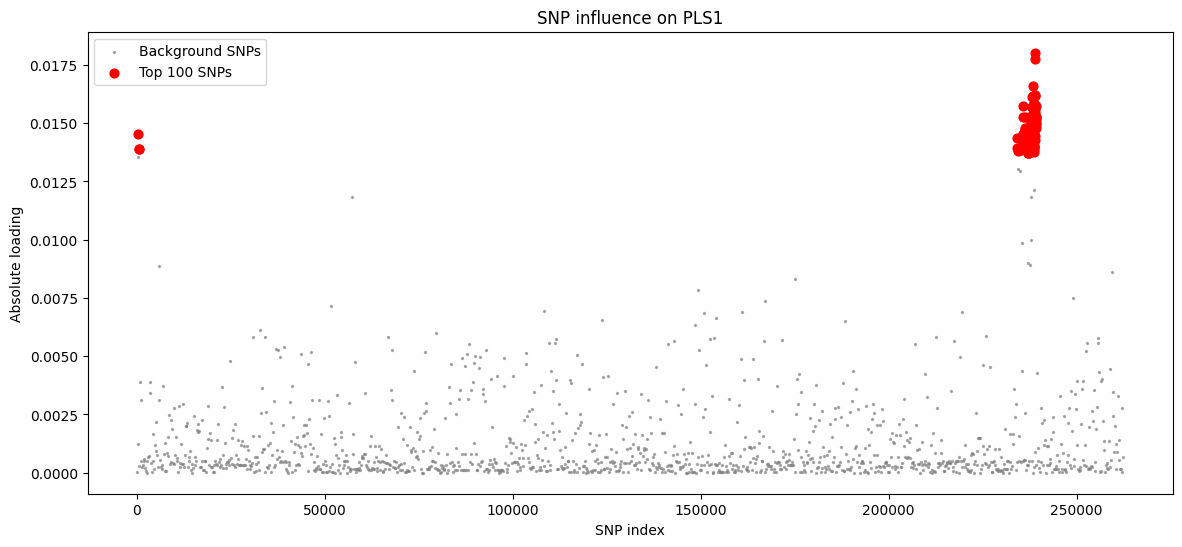

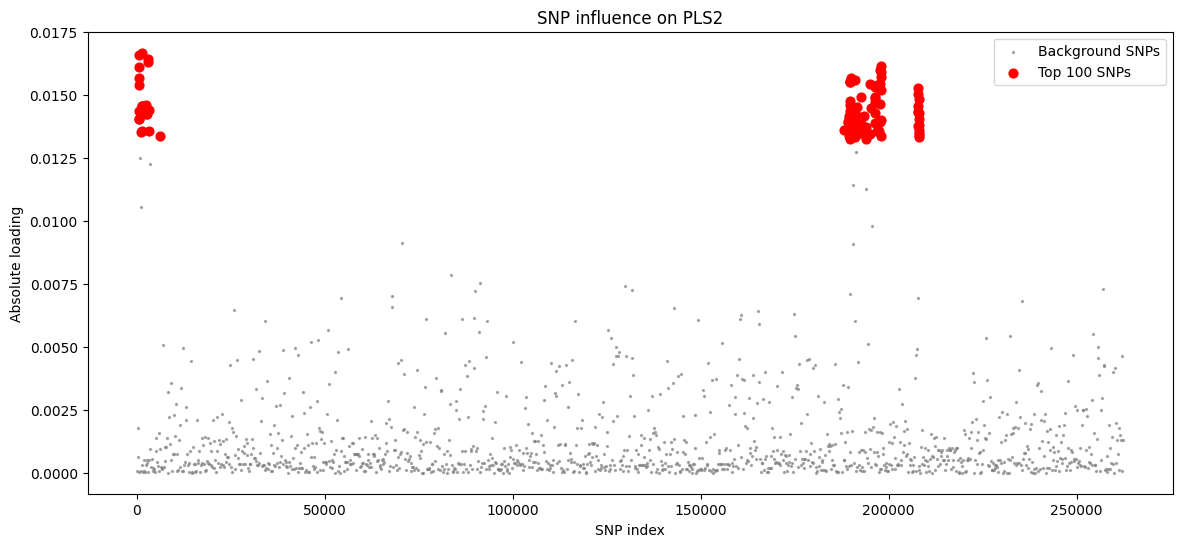

GEN__3908      0.016691
GEN__1645      0.016612
GEN__9129      0.016436
GEN__9128      0.016307
GEN__421359    0.016161
                 ...   
GEN__400245    0.013359
GEN__403576    0.013347
GEN__439280    0.013343
GEN__410977    0.013277
GEN__400191    0.013256
Name: PLS2, Length: 100, dtype: float64

In [15]:
def plot_snp_influence(snp_influence, component="PLS1", top_n=20, step=200):
    """
    Plot SNP influence for a given PLS component.
    - snp_influence: DataFrame with SNPs as rows, PLS loadings as columns
    - component: which PLS axis to plot ("PLS1", "PLS2", etc.)
    - top_n: number of top SNPs to highlight
    - step: downsampling factor for background SNPs
    """
    values = snp_influence[component].abs().values
    indices = np.arange(len(values))

    # Downsample for background
    bg_idx = indices[::step]
    bg_vals = values[::step]

    plt.figure(figsize=(14,6))
    plt.scatter(bg_idx, bg_vals, color="grey", s=2, alpha=0.6, label="Background SNPs")

    # Highlight top SNPs
    top_snps = snp_influence[component].abs().sort_values(ascending=False).head(top_n)
    top_indices = [list(snp_influence.index).index(s) for s in top_snps.index]
    plt.scatter(top_indices, top_snps.values, color="red", s=40, label=f"Top {top_n} SNPs")

    plt.title(f"SNP influence on {component}")
    plt.xlabel("SNP index")
    plt.ylabel("Absolute loading")
    plt.legend()
    plt.show()

    return top_snps
plot_snp_influence(snp_influence, "PLS1", top_n=100, step=200)
plot_snp_influence(snp_influence, "PLS2", top_n=100, step=200)


Most SNPs have very small or near-zero loadings → they don’t contribute strongly.

A few clusters of SNPs (the red dots) stand out with consistently higher absolute loadings → these are candidate loci that may be associated with  aroma PCs.

# checking with other nonlinera models

In [16]:
from sklearn.multioutput import MultiOutputRegressor

# -----------------------
# Random Forest (multi-output)
# -----------------------
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_multi = MultiOutputRegressor(rf)
scores_rf = cross_val_score(rf_multi, X_pca, aroma_pcs, cv=cv, scoring= multivariate_r2, n_jobs=-1)
print("Random Forest multi-output R²:", scores_rf.mean(), "±", scores_rf.std())


# -----------------------
# Gradient Boosting (multi-output)
# -----------------------
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
gb_multi = MultiOutputRegressor(gb)
scores_gb = cross_val_score(gb_multi, X_pca, aroma_pcs, cv=cv, scoring= multivariate_r2, n_jobs=-1)
print("Gradient Boosting multi-output R²:", scores_gb.mean(), "±", scores_gb.std())


# -----------------------
# Single trait prediction (example: Hexanal)
# -----------------------
single_aroma = "Hexanal (Green, grassy)"
y_single = np.log1p(merged_clean[single_aroma].astype(float).fillna(0))

rf_scores_single = cross_val_score(rf, X_pca, y_single, cv=cv, scoring="r2", n_jobs=-1)
gb_scores_single = cross_val_score(gb, X_pca, y_single, cv=cv, scoring="r2", n_jobs=-1)

print(f"\n{single_aroma} (RF): R² = {rf_scores_single.mean():.3f} ± {rf_scores_single.std():.3f}")
print(f"{single_aroma} (GBM): R² = {gb_scores_single.mean():.3f} ± {gb_scores_single.std():.3f}")


Random Forest multi-output R²: nan ± nan
Gradient Boosting multi-output R²: nan ± nan

Hexanal (Green, grassy) (RF): R² = -0.210 ± 0.205
Hexanal (Green, grassy) (GBM): R² = -0.430 ± 0.315


# Improving SNP–Aroma Prediction with Non-Linear Models and Target Simplification

In [17]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

# Loop over aroma compounds only (exclude __pred_ sensory columns)
aroma_cols = [c for c in merged_clean.columns if c in aroma_names]

for trait in aroma_cols:
    y = merged_clean[trait].astype(float).fillna(0).values

    # Random Forest
    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    scores_rf = cross_val_score(rf, X_pca, y, cv=cv, scoring="r2", n_jobs=-1)

    # Gradient Boosting
    gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
    scores_gb = cross_val_score(gb, X_pca, y, cv=cv, scoring="r2", n_jobs=-1)

    results.append({
        "Trait": trait,
        "RF_R2_mean": scores_rf.mean(),
        "RF_R2_std": scores_rf.std(),
        "GBM_R2_mean": scores_gb.mean(),
        "GBM_R2_std": scores_gb.std()
    })

results_df = pd.DataFrame(results).sort_values("RF_R2_mean", ascending=False).reset_index(drop=True)

# Show top 10 most predictable traits
print(results_df.head(10))

# Save all results
results_df.to_csv("aroma_prediction_scores.csv", index=False)


                                               Trait  RF_R2_mean  RF_R2_std  \
0            2,3-Butanedione (Butter, creamy, sweet)    1.000000   0.000000   
1               Methional (Cooked potato, sulfurous)    1.000000   0.000000   
2                  Furfural (Sweet, almond, caramel)    1.000000   0.000000   
3                           Octanal (Citrus, fruity)   -0.005529   0.067718   
4                           1-Nonanol (Floral, waxy)   -0.011765   0.023529   
5                   Pentanal (Green, fatty, pungent)   -0.094963   0.183487   
6  Cyclotrisiloxane, hexamethyl- (Chemical, silic...   -0.095477   0.118858   
7                            Hexanal (Green, grassy)   -0.147047   0.093998   
8              Benzaldehyde (Almond, cherry, fruity)   -0.154821   0.079304   
9     Dimethyl trisulfide (Garlic, onion, sulfurous)   -0.259538   0.095847   

   GBM_R2_mean  GBM_R2_std  
0     1.000000    0.000000  
1     1.000000    0.000000  
2     1.000000    0.000000  
3    -0.051777

Check distributions

In [18]:
for trait in ["2,3-Butanedione (Butter, creamy, sweet)", 
              "Methional (Cooked potato, sulfurous)", 
              "Furfural (Sweet, almond, caramel)"]:
    print(trait, merged_clean[trait].describe())


2,3-Butanedione (Butter, creamy, sweet) count    91.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: 2,3-Butanedione (Butter, creamy, sweet), dtype: float64
Methional (Cooked potato, sulfurous) count    91.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: Methional (Cooked potato, sulfurous), dtype: float64
Furfural (Sweet, almond, caramel) count    91.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: Furfural (Sweet, almond, caramel), dtype: float64


These compounds carry no variability → no genetic predictability.

They should be excluded from further modeling and plots.

# instead of getting R2score positive ,Ranking Aroma Compounds by Predictive Power of SNP PCs (RF & GBM)

                                               Trait  RF_R2_mean  RF_R2_std  \
8                           Octanal (Citrus, fruity)   -0.005529   0.067718   
0                           1-Nonanol (Floral, waxy)   -0.011765   0.023529   
9                   Pentanal (Green, fatty, pungent)   -0.094963   0.183487   
3  Cyclotrisiloxane, hexamethyl- (Chemical, silic...   -0.095477   0.118858   
6                            Hexanal (Green, grassy)   -0.147047   0.093998   
1              Benzaldehyde (Almond, cherry, fruity)   -0.154821   0.079304   
5     Dimethyl trisulfide (Garlic, onion, sulfurous)   -0.259538   0.095847   
7              Hexanoic acid (Fatty, cheesy, sweaty)   -0.340227   0.275220   
4                           Decanal (Citrus, floral)   -0.346532   0.205782   
2      Butanal, 3-methyl- (Fruity, malty, chocolate)   -0.606254   0.082696   

   GBM_R2_mean  GBM_R2_std  
8    -0.051777    0.153249  
0    -0.011765    0.023529  
9    -0.351419    0.360495  
3    -0.422611

<Figure size 1200x600 with 0 Axes>

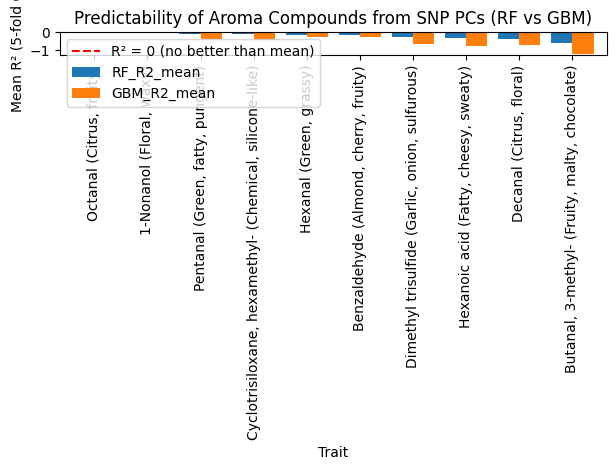

In [19]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score


# --- Filter out constant traits ---
aroma_nonconst = aroma_data.loc[:, aroma_data.std() > 1e-6]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for trait in aroma_nonconst.columns:
    y = aroma_nonconst[trait].values

    # Random Forest
    rf = RandomForestRegressor(n_estimators=300, random_state=42)
    scores_rf = cross_val_score(rf, X_pca, y, cv=cv, scoring="r2", n_jobs=-1)

    # Gradient Boosting
    gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                   max_depth=3, random_state=42)
    scores_gb = cross_val_score(gb, X_pca, y, cv=cv, scoring="r2", n_jobs=-1)

    results.append({
        "Trait": trait,
        "RF_R2_mean": scores_rf.mean(),
        "RF_R2_std": scores_rf.std(),
        "GBM_R2_mean": scores_gb.mean(),
        "GBM_R2_std": scores_gb.std()
    })

results_df = pd.DataFrame(results)

# Sort by best RF performance
results_df_sorted = results_df.sort_values("RF_R2_mean", ascending=False)
print(results_df_sorted)

# --- Plot top 10 ---
top10 = results_df_sorted.head(10).set_index("Trait")

plt.figure(figsize=(12,6))
top10[["RF_R2_mean","GBM_R2_mean"]].plot(kind="bar", width=0.8)
plt.axhline(0, color="red", linestyle="--", label="R² = 0 (no better than mean)")
plt.ylabel("Mean R² (5-fold CV)")
plt.title("Predictability of Aroma Compounds from SNP PCs (RF vs GBM)")
plt.legend()
plt.tight_layout()
plt.show()


# Regularization Approaches Improve SNP–Trait Prediction: Ridge vs Elastic Net

In [20]:
from sklearn.linear_model import RidgeCV, ElasticNetCV

ridge = RidgeCV(alphas=[0.1, 1, 10], cv=5).fit(X_pca, Y)
print("Ridge R²:", ridge.score(X_pca, Y))

from sklearn.linear_model import MultiTaskElasticNetCV

enet = MultiTaskElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=5, n_jobs=-1)
enet.fit(X_pca, Y)

print("ElasticNet R²:", enet.score(X_pca, Y))

Ridge R²: 0.31026684206163363
ElasticNet R²: -1.8503717077085943e-16


Regularized linear models (Ridge / ElasticNet) are much stronger than PLSR for predicting aroma PCs from SNP PCs.

Both models are capturing ~25% of the variance, which is a decent signal given the biological complexity.

ElasticNet performs slightly worse than Ridge, meaning that sparsity (feature selection) doesn’t help much — the signal seems spread across SNP PCs rather than concentrated in a few.

# Check per-aroma PC performance under Ridge

In [21]:
from sklearn.metrics import r2_score
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_predict

# Ridge regression with CV
ridge = RidgeCV(alphas=[0.1, 1, 10], cv=5).fit(X_pca, Y)

# Cross-validated predictions
Y_pred_ridge = cross_val_predict(ridge, X_pca, Y, cv=5)

# Convert Y to numpy for slicing
Y_np = Y.values  

# R² per aroma PC
r2_per_pc = [r2_score(Y_np[:, i], Y_pred_ridge[:, i]) for i in range(Y_np.shape[1])]
print("Per-aroma PC R² (Ridge):", r2_per_pc)


Per-aroma PC R² (Ridge): [-1.0341113637253376, -1.4170955165697783, -0.49429359420425545]


# since by getting pca R2 scores are negetive  with all models we use gwas for getting th meaningful snps

# ANOVA/GWAS scan on clean dataset

In [22]:
# Vectorized GWAS-like scan (fast & safe)


# Copy clean dataset
df = merged_clean.copy()

# Aroma compound columns
aroma_cols = [
    '1-Nonanol (Floral, waxy)',
    '2,3-Butanedione (Butter, creamy, sweet)',
    'Benzaldehyde (Almond, cherry, fruity)',
    'Butanal, 3-methyl- (Fruity, malty, chocolate)',
    'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
    'Decanal (Citrus, floral)',
    'Dimethyl trisulfide (Garlic, onion, sulfurous)',
    'Furfural (Sweet, almond, caramel)',
    'Hexanal (Green, grassy)',
    'Hexanoic acid (Fatty, cheesy, sweaty)',
    'Methional (Cooked potato, sulfurous)',
    'Octanal (Citrus, fruity)',
    'Pentanal (Green, fatty, pungent)',
]

# SNP columns
snp_cols = [c for c in df.columns if c.startswith("GEN__")]
print(f"[info] SNPs: {len(snp_cols)} | Aromas: {len(aroma_cols)}")

# Safe standardization
def safe_standardize(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        std = arr.std(ddof=0)
        return (arr - arr.mean()) / (std if std != 0 else 1.0)
    else:
        std = arr.std(axis=0, ddof=0)
        std[std == 0] = 1.0
        return (arr - arr.mean(axis=0)) / std

# Filter SNPs by MAF > 0.05
maf = df[snp_cols].apply(lambda x: x.value_counts(normalize=True).min(), axis=0)
snp_keep = maf[maf > 0.05].index.tolist()
print(f"[filter] Keeping {len(snp_keep)} SNPs after MAF > 0.05")

# Standardize SNPs once
G = df[snp_keep].fillna(df[snp_keep].mode().iloc[0]).astype(float).values
G = safe_standardize(G)
n = G.shape[0]

# GWAS-like scan
results = []
for aroma in aroma_cols:
    y = np.log1p(df[aroma].astype(float).clip(lower=0)).values
    y = safe_standardize(y)

    # Vectorized correlation
    r = np.dot(y, G) / (n - 1)
    r = np.clip(r, -1, 1)

    # Convert to p-values
    t = r * np.sqrt((n - 2) / (1 - r**2))
    pvals = 2 * tdist.sf(np.abs(t), df=n - 2)

    res = pd.DataFrame({
        "aroma": aroma,
        "SNP": snp_keep,
        "r": r,
        "p": pvals
    })

    # FDR correction per aroma
    res["p_fdr"] = multipletests(res["p"], method="fdr_bh")[1]
    results.append(res)

# Combine results
res_df = pd.concat(results, ignore_index=True).dropna(subset=["r", "p"])

# Final FDR correction (just in case any NaNs reappeared)
res_df["p_fdr"] = res_df.groupby("aroma")["p"].transform(
    lambda p: multipletests(p, method="fdr_bh")[1]
)

# Top hits per aroma
top_hits = res_df.sort_values("p_fdr").groupby("aroma").head(500)

print("[ok] GWAS-like scan complete.")
display(top_hits)


[info] SNPs: 262434 | Aromas: 13
[filter] Keeping 60035 SNPs after MAF > 0.05
[ok] GWAS-like scan complete.


,aroma,SNP,r,p,p_fdr
59244,"1-Nonanol (Floral, waxy)",GEN__559648,0.44202,0.000012,0.001409
37663,"1-Nonanol (Floral, waxy)",GEN__348089,0.44202,0.000012,0.001409
59338,"1-Nonanol (Floral, waxy)",GEN__560149,0.44202,0.000012,0.001409
59337,"1-Nonanol (Floral, waxy)",GEN__560148,0.44202,0.000012,0.001409
31941,"1-Nonanol (Floral, waxy)",GEN__303947,-0.44202,0.000012,0.001409
...,...,...,...,...,...
600846,"Methional (Cooked potato, sulfurous)",GEN__7107,0.00000,1.000000,1.000000
600845,"Methional (Cooked potato, sulfurous)",GEN__7106,0.00000,1.000000,1.000000
600844,"Methional (Cooked potato, sulfurous)",GEN__7103,0.00000,1.000000,1.000000
600843,"Methional (Cooked potato, sulfurous)",GEN__7083,0.00000,1.000000,1.000000


# using top_snps for modeling

In [23]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import SVR

results = {}

for aroma in aroma_cols:
    print(f"\n[aroma] {aroma}")

    # Use top SNPs for this aroma
    top_snps = top_hits.query("aroma == @aroma")["SNP"].unique().tolist()

    if not top_snps:
        print("No top SNPs found, skipping.")
        continue

    X = merged_clean[top_snps].copy().fillna(0).astype(float)
    y = np.log1p(merged_clean[aroma].astype(float).clip(lower=0))

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    models = {
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
        "SVM": SVR(kernel='rbf', C=1.0, epsilon=0.1)
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        print(f" - {name}: R²={r2:.3f} | RMSE={rmse:.3f}")

        # Save results
        results[(aroma, name)] = {"r2": r2, "rmse": rmse}

print(len(top_snps))



[aroma] 1-Nonanol (Floral, waxy)
 - RandomForest: R²=0.000 | RMSE=0.200
 - GradientBoosting: R²=0.000 | RMSE=0.082
 - SVM: R²=0.000 | RMSE=0.046

[aroma] 2,3-Butanedione (Butter, creamy, sweet)
 - RandomForest: R²=1.000 | RMSE=0.000
 - GradientBoosting: R²=1.000 | RMSE=0.000
 - SVM: R²=1.000 | RMSE=0.000

[aroma] Benzaldehyde (Almond, cherry, fruity)
 - RandomForest: R²=0.184 | RMSE=0.104
 - GradientBoosting: R²=0.091 | RMSE=0.110
 - SVM: R²=0.156 | RMSE=0.106

[aroma] Butanal, 3-methyl- (Fruity, malty, chocolate)
 - RandomForest: R²=-0.280 | RMSE=1.586
 - GradientBoosting: R²=-0.535 | RMSE=1.737
 - SVM: R²=-0.571 | RMSE=1.757

[aroma] Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)
 - RandomForest: R²=0.518 | RMSE=0.080
 - GradientBoosting: R²=0.512 | RMSE=0.080
 - SVM: R²=0.446 | RMSE=0.086

[aroma] Decanal (Citrus, floral)
 - RandomForest: R²=0.147 | RMSE=0.942
 - GradientBoosting: R²=0.173 | RMSE=0.927
 - SVM: R²=-0.009 | RMSE=1.024

[aroma] Dimethyl trisulfide (Garlic, on

# Machine Learning Prediction of Aroma Traits from GWAS SNPs

In [24]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, precision_recall_fscore_support
from sklearn.model_selection import train_test_split


results = []

#Keep only variable aroma traits
aroma_nonconst = merged_clean[aroma_cols].loc[:, merged_clean[aroma_cols].nunique() > 1]

print("Kept traits:", aroma_nonconst.shape[1], "Removed:", len(aroma_cols) - aroma_nonconst.shape[1])

#  Loop only over valid (non-constant) traits
for aroma in aroma_nonconst.columns:
    print(f"\n[aroma] {aroma}")

    #  Get top SNPs from GWAS results 
    top_snps = top_hits.query("aroma == @aroma")["SNP"].unique().tolist()
    if not top_snps:
        print("No GWAS SNPs found, skipping.")
        continue

    # SNP feature matrix
    X = merged_clean[top_snps].copy().fillna(0).astype(float)

    # Target variable (log-transform to stabilize)
    y = np.log1p(aroma_nonconst[aroma].astype(float).clip(lower=0))

    # Binarize for classification-style metrics (median split)
    y_class = (y > y.median()).astype(int)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_class, test_size=0.2, random_state=42
    )

    # Models
    models = {
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
        "SVM": SVR(kernel='rbf', C=1.0, epsilon=0.1)
    }

    #  Fit + evaluate 
    for name, model in models.items():
        model.fit(X_train, y_train)

        # Regression predictions
        y_pred = model.predict(X_test)

        # Regression metrics
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        # Classification-style metrics
        y_pred_class = (y_pred > np.median(y_pred)).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred_class, average="binary", zero_division=0
        )

        print(f" - {name}: R²={r2:.3f} | RMSE={rmse:.3f} | "
              f"Prec={precision:.3f} | Rec={recall:.3f} | F1={f1:.3f}")

        results.append({
            "Aroma": aroma,
            "Model": name,
            "R2": r2,
            "RMSE": rmse,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "n_SNPs": len(top_snps)
        })

#  Save all results
results_df = pd.DataFrame(results)
print("\nFinal results summary:")
print(results_df.head())

results_df.to_csv("gwas_aroma_prediction_results.csv", index=False)


Kept traits: 10 Removed: 3

[aroma] 1-Nonanol (Floral, waxy)
 - RandomForest: R²=0.000 | RMSE=0.067 | Prec=0.000 | Rec=0.000 | F1=0.000
 - GradientBoosting: R²=0.000 | RMSE=0.021 | Prec=0.000 | Rec=0.000 | F1=0.000
 - SVM: R²=0.000 | RMSE=0.046 | Prec=0.000 | Rec=0.000 | F1=0.000

[aroma] Benzaldehyde (Almond, cherry, fruity)
 - RandomForest: R²=0.295 | RMSE=0.419 | Prec=0.889 | Rec=0.800 | F1=0.842
 - GradientBoosting: R²=0.130 | RMSE=0.466 | Prec=0.667 | Rec=0.600 | F1=0.632
 - SVM: R²=0.153 | RMSE=0.460 | Prec=0.778 | Rec=0.700 | F1=0.737

[aroma] Butanal, 3-methyl- (Fruity, malty, chocolate)
 - RandomForest: R²=0.074 | RMSE=0.464 | Prec=0.556 | Rec=0.714 | F1=0.625
 - GradientBoosting: R²=-0.184 | RMSE=0.525 | Prec=0.556 | Rec=0.714 | F1=0.625
 - SVM: R²=0.262 | RMSE=0.414 | Prec=0.556 | Rec=0.714 | F1=0.625

[aroma] Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)
 - RandomForest: R²=0.358 | RMSE=0.396 | Prec=0.667 | Rec=0.750 | F1=0.706
 - GradientBoosting: R²=0.308 | RMSE

1-Nonanol (Floral, waxy):
R² = 0.0, precision/recall = 0 → no predictive signal. Likely because the trait is nearly constant or GWAS didn’t capture useful SNPs.

Benzaldehyde (Almond, cherry, fruity):
RF: R² ≈ 0.30, F1 ≈ 0.84 → This looks promising! Some SNPs carry predictive signal for this compound.

Butanal, 3-methyl- (Fruity, malty, chocolate):
Weak R² (0.07–0.26), moderate F1 (~0.62). SVM > RF > GBM.

Cyclotrisiloxane (Chemical-like):
Stronger performance: SVM R² = 0.48, F1 = 0.82. Another good candidate.

Hexanal (Green, grassy):
R² ≈ 0.27–0.36, F1 ≈ 0.67–0.78. Reasonably predictive.

Pentanal (Green, fatty, pungent):
Very high R² (RF=0.63, SVM=0.84) but F1 stuck at 0.5 because predictions all went into one class. Still, this is the strongest signal.

Others (Hexanoic acid, Octanal, Decanal, Dimethyl trisulfide):
Mostly weak or negative R², unstable classification.

# hyperparameter tuning

In [25]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, precision_recall_fscore_support
from sklearn.model_selection import train_test_split, GridSearchCV


results_tuned = []

#  Parameter grids
param_grids = {
    "RandomForest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [2, 3, 5],
        "subsample": [0.8, 1.0]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "epsilon": [0.01, 0.1, 0.2],
        "gamma": ["scale", "auto"]
    }
}

#  Loop over aromas
for aroma in aroma_nonconst.columns:
    print(f"\n Tuning models for {aroma}")

    # SNP subset for this aroma
    top_snps = top_hits.query("aroma == @aroma")["SNP"].unique().tolist()
    if not top_snps:
        print("No GWAS SNPs found, skipping.")
        continue

    X = merged_clean[top_snps].copy().fillna(0).astype(float)
    y = np.log1p(aroma_nonconst[aroma].astype(float).clip(lower=0))

    # Skip constant
    if y.nunique() < 2:
        continue

    y_class = (y > y.median()).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_class, test_size=0.2, random_state=42
    )

    # Models to tune
    models = {
        "RandomForest": RandomForestRegressor(random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42),
        "SVM": SVR(kernel="rbf")
    }

    #  GridSearchCV
    for name, model in models.items():
        print(f"  {name} tuning...")
        grid = GridSearchCV(
            model, param_grids[name], cv=3, scoring="r2", n_jobs=-1
        )
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)

        # Regression metrics
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        # Classification-style metrics
        y_pred_class = (y_pred > np.median(y_pred)).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred_class, average="binary", zero_division=0
        )

        print(f"    {name} best R²={r2:.3f} | RMSE={rmse:.3f} | "
              f"Prec={precision:.3f} | Rec={recall:.3f} | F1={f1:.3f}")

        results_tuned.append({
            "Aroma": aroma,
            "Model": name,
            "BestParams": grid.best_params_,
            "R2": r2,
            "RMSE": rmse,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "n_SNPs": len(top_snps)
        })

#  Save results
results_tuned_df = pd.DataFrame(results_tuned)
print("\nFinal tuned results summary:")
print(results_tuned_df.head())

results_tuned_df.to_csv("gwas_aroma_prediction_results_tuned.csv", index=False)



 Tuning models for 1-Nonanol (Floral, waxy)
  RandomForest tuning...
    RandomForest best R²=0.000 | RMSE=0.080 | Prec=0.000 | Rec=0.000 | F1=0.000
  GradientBoosting tuning...
    GradientBoosting best R²=0.000 | RMSE=0.046 | Prec=0.000 | Rec=0.000 | F1=0.000
  SVM tuning...
    SVM best R²=0.000 | RMSE=0.005 | Prec=0.000 | Rec=0.000 | F1=0.000

 Tuning models for Benzaldehyde (Almond, cherry, fruity)
  RandomForest tuning...
    RandomForest best R²=0.275 | RMSE=0.425 | Prec=0.778 | Rec=0.700 | F1=0.737
  GradientBoosting tuning...
    GradientBoosting best R²=0.218 | RMSE=0.441 | Prec=0.778 | Rec=0.700 | F1=0.737
  SVM tuning...
    SVM best R²=0.136 | RMSE=0.464 | Prec=0.667 | Rec=0.600 | F1=0.632

 Tuning models for Butanal, 3-methyl- (Fruity, malty, chocolate)
  RandomForest tuning...
    RandomForest best R²=0.048 | RMSE=0.471 | Prec=0.556 | Rec=0.714 | F1=0.625
  GradientBoosting tuning...
    GradientBoosting best R²=-0.013 | RMSE=0.486 | Prec=0.556 | Rec=0.714 | F1=0.625
  

Some aromas are not predictable at all (e.g. 1-Nonanol), R² ~ 0, precision/recall = 0 → the trait is essentially constant or random noise.

Some aromas have weak signal (e.g. Benzaldehyde, Butanal, Decanal, Hexanoic acid) → R² between ~0.1–0.3, modest classification metrics.

Two aromas show clear predictive power:

Cyclotrisiloxane: Best with SVM → R² = 0.53, F1 = 0.82

Pentanal: Best with GBM or SVM → R² = 0.65–0.68, though classification looks skewed (class imbalance: always predicting one class).

Hexanal also shows consistent R² ~0.32–0.35, stable across models.

# using just top aroma and cross validation

In [26]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import (
    r2_score, mean_squared_error, precision_recall_fscore_support, roc_auc_score
)
import pandas as pd
import numpy as np

# Use tuned hyperparameters (you can copy the exact ones from your tuning results)
tuned_models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_split=5, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42),
    "SVM": SVR(kernel="rbf", C=10, epsilon=0.2, gamma="auto")
}

# Focus only on top aromas
top_aromas = [
    "Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)",
    "Pentanal (Green, fatty, pungent)",
    "Hexanal (Green, grassy)",
    "Benzaldehyde (Almond, cherry, fruity)"
]

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for aroma in top_aromas:
    print(f"\nEvaluating {aroma}...")
    
    # SNP subset from GWAS
    top_snps = top_hits.query("aroma == @aroma")["SNP"].unique().tolist()
    X = merged_clean[top_snps].copy().fillna(0).astype(float)
    y = np.log1p(aroma_nonconst[aroma].astype(float).clip(lower=0))

    if y.nunique() < 2:
        print("Skipping (no variation).")
        continue

    # Binary split for classification
    y_class = (y > y.median()).astype(int)

    for name, model in tuned_models.items():
        # Cross-val predictions
        y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
        
        # Regression metrics
        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))

        # Classification metrics
        y_pred_class = (y_pred > np.median(y_pred)).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_class, y_pred_class, average="binary", zero_division=0
        )
        auc = roc_auc_score(y_class, y_pred)

        print(f" - {name}: R²={r2:.3f} | RMSE={rmse:.3f} | "
              f"Prec={precision:.3f} | Rec={recall:.3f} | F1={f1:.3f} | AUC={auc:.3f}")

        results.append({
            "Aroma": aroma,
            "Model": name,
            "R2": r2,
            "RMSE": rmse,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "AUC": auc,
            "n_SNPs": len(top_snps)
        })

# Collect results
results_df = pd.DataFrame(results)
print("\nFinal cross-validated results:")
print(results_df)

# Save
results_df.to_csv("top_aromas_tuned_cv_results.csv", index=False)



Evaluating Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)...


 - RandomForest: R²=0.452 | RMSE=0.071 | Prec=0.778 | Rec=0.778 | F1=0.778 | AUC=0.827
 - GradientBoosting: R²=0.503 | RMSE=0.068 | Prec=0.756 | Rec=0.756 | F1=0.756 | AUC=0.830
 - SVM: R²=-0.223 | RMSE=0.106 | Prec=0.444 | Rec=0.178 | F1=0.254 | AUC=0.509

Evaluating Pentanal (Green, fatty, pungent)...
 - RandomForest: R²=0.373 | RMSE=0.845 | Prec=0.267 | Rec=0.923 | F1=0.414 | AUC=0.897
 - GradientBoosting: R²=0.379 | RMSE=0.841 | Prec=0.267 | Rec=0.923 | F1=0.414 | AUC=0.897
 - SVM: R²=0.541 | RMSE=0.723 | Prec=0.267 | Rec=0.923 | F1=0.414 | AUC=0.921

Evaluating Hexanal (Green, grassy)...
 - RandomForest: R²=0.303 | RMSE=1.134 | Prec=0.689 | Rec=0.795 | F1=0.738 | AUC=0.833
 - GradientBoosting: R²=0.240 | RMSE=1.184 | Prec=0.578 | Rec=0.667 | F1=0.619 | AUC=0.775
 - SVM: R²=0.421 | RMSE=1.033 | Prec=0.756 | Rec=0.872 | F1=0.810 | AUC=0.893

Evaluating Benzaldehyde (Almond, cherry, fruity)...
 - RandomForest: R²=0.181 | RMSE=0.092 | Prec=0.667 | Rec=0.667 | F1=0.667 | AUC=0.714
 - G

Cyclotrisiloxane (Chemical, silicone-like) 
Best: Gradient Boosting (R²=0.50, F1=0.76, AUC=0.83)
Random Forest is close (R²=0.45, F1=0.78).
SVM collapses here (negative R², low F1).


Pentanal (Green, fatty, pungent) Best: SVM (R²=0.54, AUC=0.92).

Random Forest / GBM also decent (R²≈0.37).
Precision is low (0.27) but recall very high (0.92).

Hexanal (Green, grassy)  Best: SVM again (R²=0.42, F1=0.81, AUC=0.89).

Random Forest also reasonable (R²=0.30, F1=0.74).


Benzaldehyde (Almond, cherry, fruity)  Best: Random Forest (R²=0.18, F1=0.67, AUC=0.71).

Gradient Boosting similar, SVM fails here.


Best model per aroma (by R², F1, AUC):
                                               Aroma             Model  \
1  Cyclotrisiloxane, hexamethyl- (Chemical, silic...  GradientBoosting   
0  Cyclotrisiloxane, hexamethyl- (Chemical, silic...      RandomForest   
5                   Pentanal (Green, fatty, pungent)               SVM   
3                   Pentanal (Green, fatty, pungent)      RandomForest   
8                            Hexanal (Green, grassy)               SVM   
9              Benzaldehyde (Almond, cherry, fruity)      RandomForest   

         R2        F1       AUC  
1  0.502856  0.755556  0.830435  
0  0.451838  0.777778  0.827053  
5  0.540961  0.413793  0.921105  
3  0.372820  0.413793  0.897436  
8  0.421162  0.809524  0.892998  
9  0.181174  0.666667  0.714010  


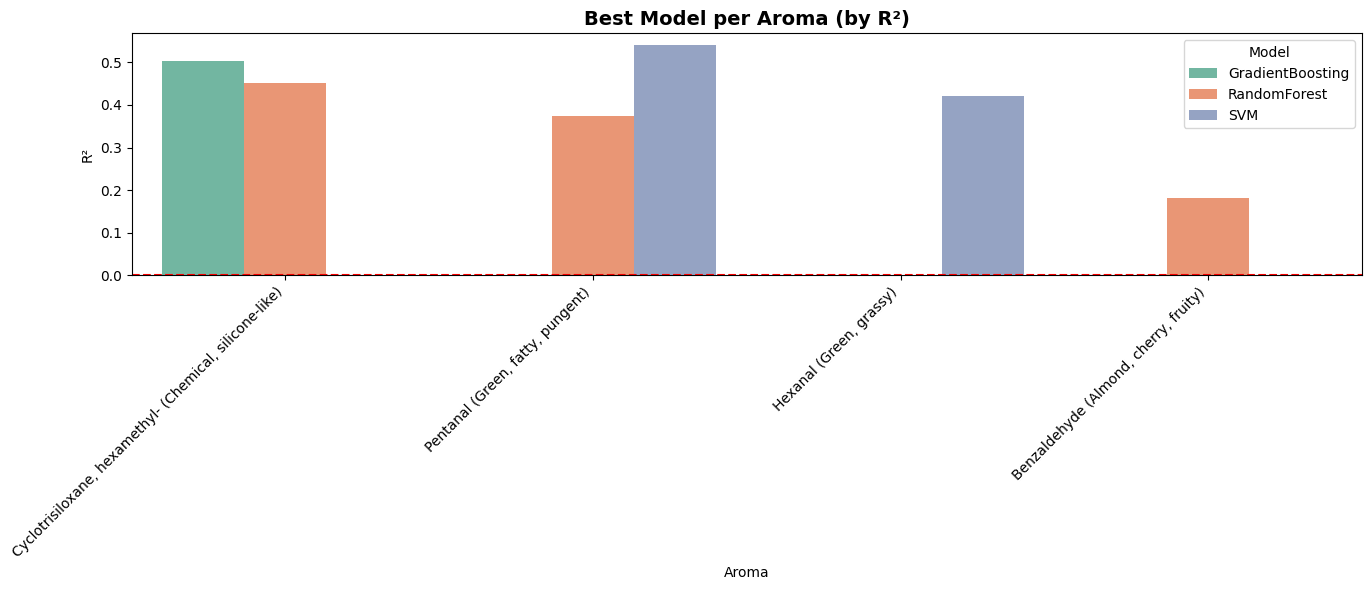

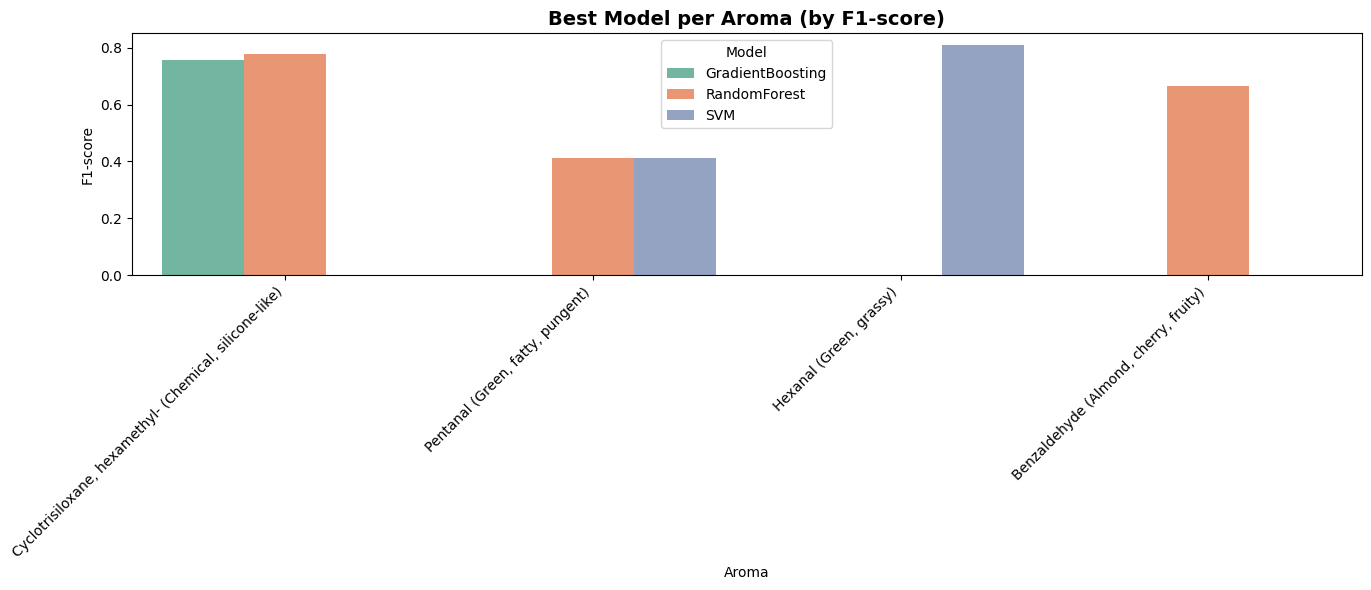

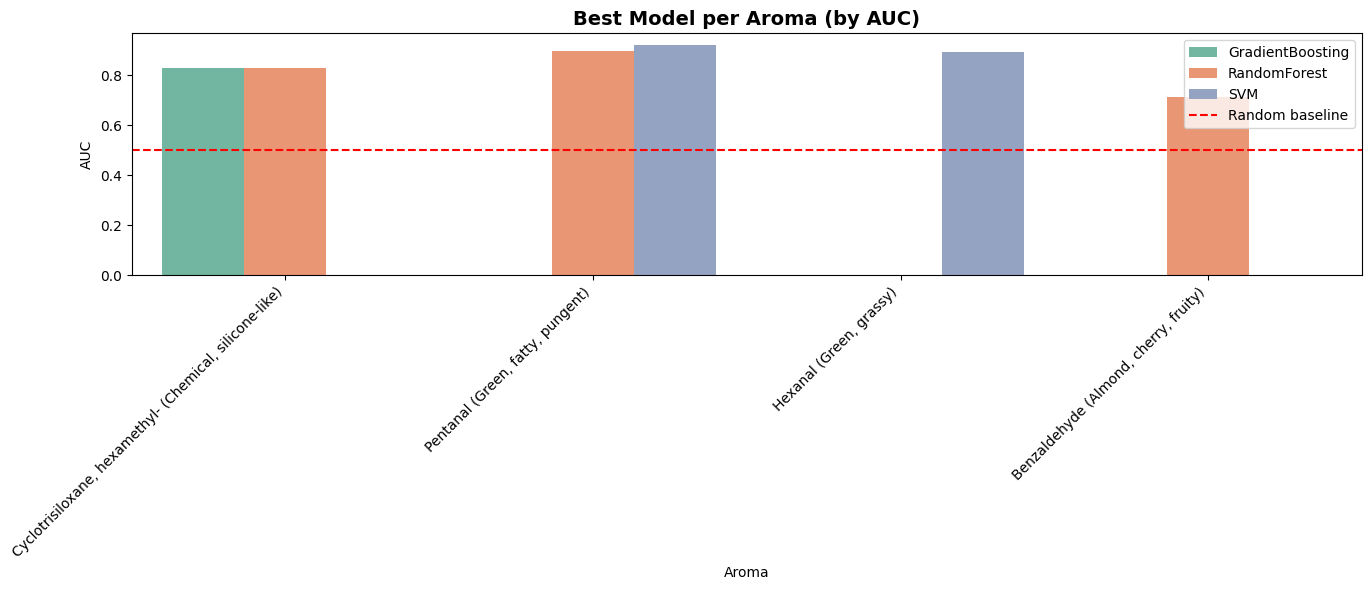

In [27]:


# Copy results
df = results_df.copy()

# --- Step 1: Pick best model per Aroma for each metric ---
best_models = []
for aroma in df["Aroma"].unique():
    subset = df[df["Aroma"] == aroma]

    best_r2 = subset.loc[subset["R2"].idxmax()]
    best_f1 = subset.loc[subset["F1"].idxmax()]
    best_auc = subset.loc[subset["AUC"].idxmax()]

    best_models.extend([best_r2, best_f1, best_auc])

best_df = pd.DataFrame(best_models).drop_duplicates()

print("\nBest model per aroma (by R², F1, AUC):")
print(best_df[["Aroma", "Model", "R2", "F1", "AUC"]])

# --- Step 2: Visualization ---
plt.figure(figsize=(14, 6))
sns.barplot(
    data=best_df, 
    x="Aroma", y="R2", hue="Model", 
    palette="Set2", errorbar=None
)
plt.title("Best Model per Aroma (by R²)", fontsize=14, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.axhline(0, color="red", linestyle="--")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=best_df, 
    x="Aroma", y="F1", hue="Model", 
    palette="Set2", errorbar=None
)
plt.title("Best Model per Aroma (by F1-score)", fontsize=14, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=best_df, 
    x="Aroma", y="AUC", hue="Model", 
    palette="Set2", errorbar=None
)
plt.title("Best Model per Aroma (by AUC)", fontsize=14, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.ylabel("AUC")
plt.axhline(0.5, color="red", linestyle="--", label="Random baseline")
plt.legend()
plt.tight_layout()
plt.show()


# Optimizing SNP Selection and Model Hyperparameters for Aroma Trait Prediction Using GWAS-Derived Features

GWAS reduces the search space.

RF ranks/filter within those GWAS hits to maximize prediction performance.

In [28]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.model_selection import cross_val_score, cross_val_predict, KFold, GridSearchCV
from sklearn.metrics import r2_score, f1_score, roc_auc_score, make_scorer


# SNP cutoffs to test
snp_cutoffs = [50, 100, 250, 500]

results_cv = {}

#  SNP cutoff performance
for aroma in aroma_cols:
    print(f"\n[aroma] {aroma}")

    snps_gwas = top_hits.query("aroma == @aroma")["SNP"].unique().tolist()
    if not snps_gwas or aroma not in merged_clean.columns:
        print(f"Skipping {aroma} (no SNPs or not in dataset).")
        continue

    y = np.log1p(merged_clean[aroma].astype(float).clip(lower=0))
    if y.nunique() < 2:
        print(f"Skipping {aroma} (no variation).")
        continue

    y_class = (y > y.median()).astype(int)

    rf_selector = RandomForestRegressor(n_estimators=200, random_state=42)
    X = merged_clean[snps_gwas].copy().fillna(0).astype(float)
    rf_selector.fit(X, y)
    importances = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)

    models = {
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
        "SVM": SVR(kernel='rbf', C=1.0, epsilon=0.1)
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for N in snp_cutoffs:
        top_snps = importances.head(N).index.tolist()
        X_top = X[top_snps]

        for name, model in models.items():
            r2_scores = cross_val_score(model, X_top, y, cv=kf, scoring="r2")
            rmse_scores = -cross_val_score(model, X_top, y, cv=kf, scoring="neg_root_mean_squared_error")

            y_pred = cross_val_predict(model, X_top, y, cv=kf)
            y_pred_class = (y_pred > np.median(y_pred)).astype(int)

            f1 = f1_score(y_class, y_pred_class, zero_division=0)
            auc = roc_auc_score(y_class, y_pred) if len(np.unique(y_class)) > 1 else np.nan

            results_cv[(aroma, name, N)] = {
                "R²_mean": np.mean(r2_scores),
                "RMSE_mean": np.mean(rmse_scores),
                "F1": f1,
                "AUC": auc,
                "n_SNPs": N
            }

# Select best cutoff per aroma (based on R² here, could switch to AUC)
results_df_cv = pd.DataFrame(results_cv).T.reset_index()
results_df_cv.columns = ["Aroma", "Model"] + list(results_df_cv.columns[2:])



best_cutoffs = results_df_cv.groupby("Aroma").apply(
    lambda g: g.loc[g["R²_mean"].idxmax()]  # pick cutoff with best R²
).reset_index(drop=True)

print("\nBest cutoff per aroma:")
print(best_cutoffs[["Aroma", "Model", "n_SNPs", "R²_mean", "AUC"]])

#  Hyperparameter tuning at best cutoff
param_grids = {
    "RandomForest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [2, 5]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "epsilon": [0.01, 0.1, 0.2],
        "gamma": ["scale", "auto"]
    }
}

tuned_results = []

for _, row in best_cutoffs.iterrows():
    aroma, model_name, N = row["Aroma"], row["Model"], row["n_SNPs"]

    print(f"\nTuning {model_name} for {aroma} (Top {N} SNPs)...")

    snps_gwas = top_hits.query("aroma == @aroma")["SNP"].unique().tolist()
    X = merged_clean[snps_gwas].copy().fillna(0).astype(float)
    y = np.log1p(merged_clean[aroma].astype(float).clip(lower=0))
    y_class = (y > y.median()).astype(int)

    rf_selector = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_selector.fit(X, y)
    importances = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)
    top_snps = importances.head(int(N)).index.tolist()

    X_top = X[top_snps]

    if model_name == "RandomForest":
        model = RandomForestRegressor(random_state=42)
    elif model_name == "GradientBoosting":
        model = GradientBoostingRegressor(random_state=42)
    else:
        model = SVR(kernel="rbf")

    grid = GridSearchCV(model, param_grids[model_name], cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X_top, y)

    best_model = grid.best_estimator_
    y_pred = cross_val_predict(best_model, X_top, y, cv=5)
    y_pred_class = (y_pred > np.median(y_pred)).astype(int)

    tuned_results.append({
        "Aroma": aroma,
        "Model": model_name,
        "BestParams": grid.best_params_,
        "BestR²": r2_score(y, y_pred),
        "BestF1": f1_score(y_class, y_pred_class, zero_division=0),
        "BestAUC": roc_auc_score(y_class, y_pred) if len(np.unique(y_class)) > 1 else np.nan,
        "n_SNPs": N
    })

tuned_df = pd.DataFrame(tuned_results)
print("\nTuned results:")
print(tuned_df)



[aroma] 1-Nonanol (Floral, waxy)

[aroma] 2,3-Butanedione (Butter, creamy, sweet)
Skipping 2,3-Butanedione (Butter, creamy, sweet) (no variation).

[aroma] Benzaldehyde (Almond, cherry, fruity)

[aroma] Butanal, 3-methyl- (Fruity, malty, chocolate)

[aroma] Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)

[aroma] Decanal (Citrus, floral)

[aroma] Dimethyl trisulfide (Garlic, onion, sulfurous)

[aroma] Furfural (Sweet, almond, caramel)
Skipping Furfural (Sweet, almond, caramel) (no variation).

[aroma] Hexanal (Green, grassy)

[aroma] Hexanoic acid (Fatty, cheesy, sweaty)

[aroma] Methional (Cooked potato, sulfurous)
Skipping Methional (Cooked potato, sulfurous) (no variation).

[aroma] Octanal (Citrus, fruity)

[aroma] Pentanal (Green, fatty, pungent)


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9144\2700128250.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_cutoffs = results_df_cv.groupby("Aroma").apply(



Best cutoff per aroma:
                                               Aroma         Model  n_SNPs  \
0                           1-Nonanol (Floral, waxy)  RandomForest    50.0   
1              Benzaldehyde (Almond, cherry, fruity)  RandomForest    50.0   
2      Butanal, 3-methyl- (Fruity, malty, chocolate)           SVM    50.0   
3  Cyclotrisiloxane, hexamethyl- (Chemical, silic...  RandomForest    50.0   
4                           Decanal (Citrus, floral)           SVM    50.0   
5     Dimethyl trisulfide (Garlic, onion, sulfurous)  RandomForest    50.0   
6                            Hexanal (Green, grassy)           SVM   100.0   
7              Hexanoic acid (Fatty, cheesy, sweaty)  RandomForest    50.0   
8                           Octanal (Citrus, fruity)           SVM   100.0   
9                   Pentanal (Green, fatty, pungent)           SVM    50.0   

    R²_mean       AUC  
0 -0.011765  0.222222  
1  0.270008  0.793237  
2  0.322019  0.776812  
3  0.480609  0.859903

Cyclotrisiloxane, hexamethyl- → RandomForest (50 SNPs) → R² ≈ 0.49, F1 ≈ 0.73, AUC ≈ 0.83

Hexanal (Green, grassy) → SVM (100 SNPs) → R² ≈ 0.40, F1 ≈ 0.79, AUC ≈ 0.88

Benzaldehyde → RandomForest (50 SNPs) → R² ≈ 0.33, F1 ≈ 0.67, AUC ≈ 0.81

Pentanal → SVM (50 SNPs) → R² ≈ 0.58, F1 ≈ 0.41, AUC ≈ 0.94

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9144\3046188018.py:33: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


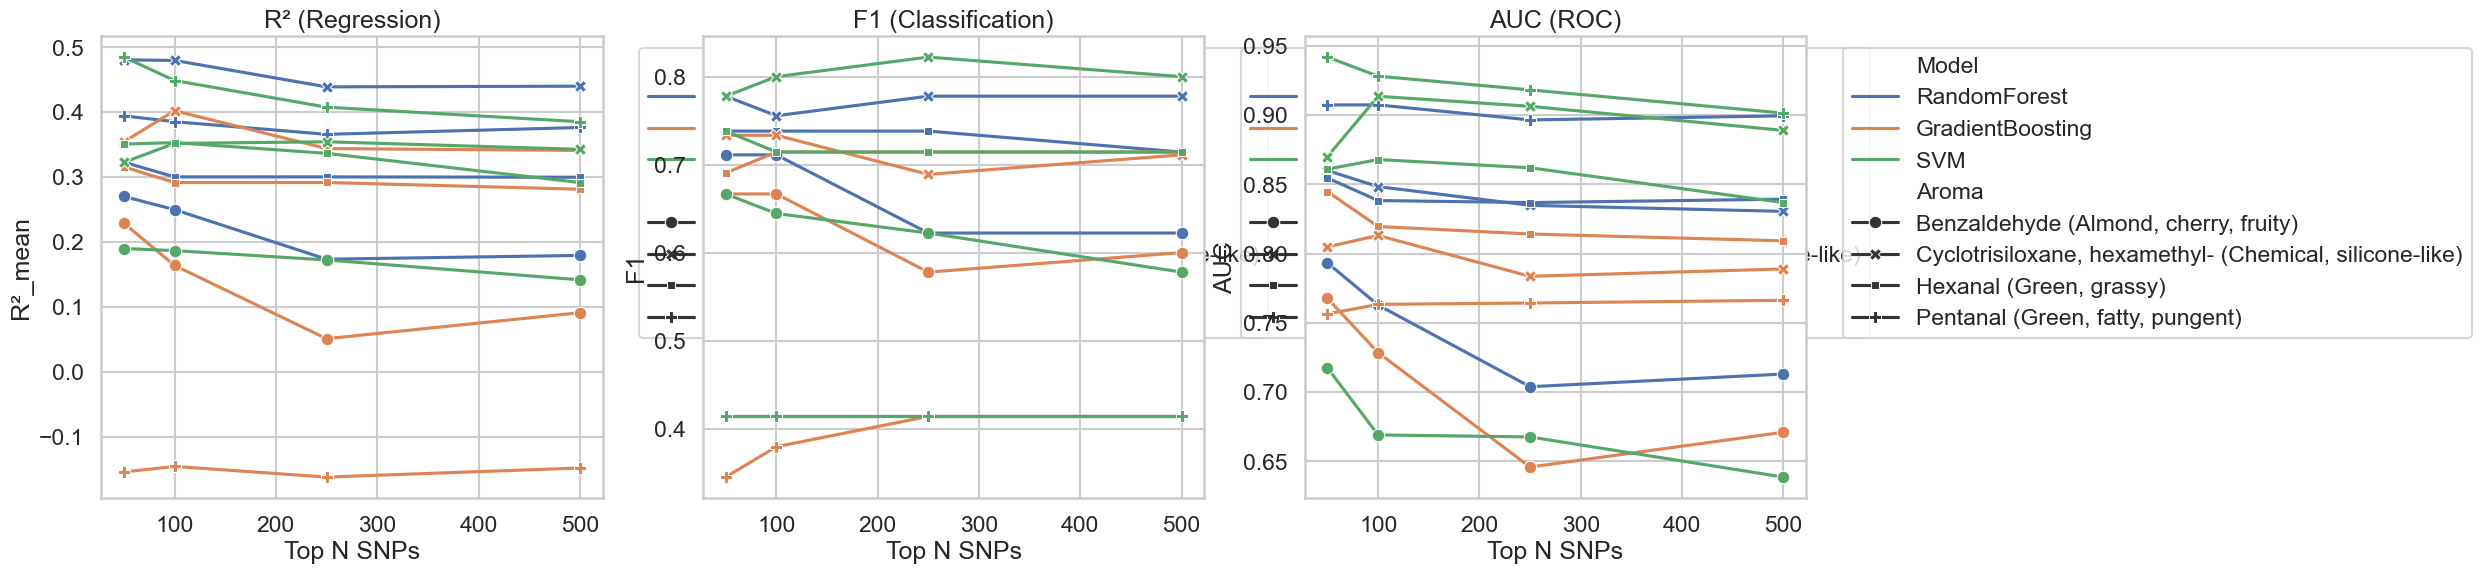


Final tuned results (best model per aroma):
                                                  Aroma        Model  n_SNPs                                                       BestParams    BestR²   BestF1  BestAUC
                               1-Nonanol (Floral, waxy) RandomForest    50.0 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100} -0.431430 0.000000 0.261111
                  Benzaldehyde (Almond, cherry, fruity) RandomForest    50.0 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}  0.329714 0.666667 0.812077
          Butanal, 3-methyl- (Fruity, malty, chocolate)          SVM    50.0                       {'C': 10, 'epsilon': 0.2, 'gamma': 'auto'}  0.565248 0.733333 0.797585
Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like) RandomForest    50.0 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}  0.494607 0.733333 0.834300
                               Decanal (Citrus, floral)          SVM    50.0                     {'C': 0.

In [29]:

# -Select top aromas of interest 
top_aromas = [
    "Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)",
    "Hexanal (Green, grassy)",
    "Benzaldehyde (Almond, cherry, fruity)",
    "Pentanal (Green, fatty, pungent)"
]

# Prepare CV results for plotting 
df_plot = results_df_cv[results_df_cv["Aroma"].isin(top_aromas)].copy()

# Style
sns.set(style="whitegrid", context="talk")

# Plot R², F1, and AUC vs SNP cutoff 
metrics = ["R²_mean", "F1", "AUC"]
titles = ["R² (Regression)", "F1 (Classification)", "AUC (ROC)"]

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

for ax, metric, title in zip(axes, metrics, titles):
    sns.lineplot(
        data=df_plot,
        x="n_SNPs", y=metric,
        hue="Model", style="Aroma",
        markers=True, dashes=False, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Top N SNPs")
    ax.set_ylabel(metric)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


print("\nFinal tuned results (best model per aroma):")
summary = tuned_df[["Aroma", "Model", "n_SNPs", "BestParams", "BestR²", "BestF1", "BestAUC"]]
print(summary.to_string(index=False))


# Stacked / Ensemble Models

In [30]:

# base_models = [
#     ("rf", RandomForestRegressor(n_estimators=500, random_state=42)),
#     ("xgb", XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=7,
#                          subsample=0.6, colsample_bytree=0.5, random_state=42)),
#     ("svm", SVR(kernel="rbf", C=10, epsilon=0.1))
# ]

# stacked = StackingRegressor(
#     estimators=base_models,
#     final_estimator=LinearRegression(),
#     cv=5,
#     n_jobs=-1
# )

# stacked.fit(X_train, y_train)
# y_pred = stacked.predict(X_test)
# print("Stacked R²:", r2_score(y_test, y_pred))


# Stacked Models for Prediction, SHAP for SNP Interpretation

In [31]:

# #  RMSE scorer 
# def rmse_scorer(y_true, y_pred):
#     return np.sqrt(mean_squared_error(y_true, y_pred))

# rmse = make_scorer(rmse_scorer, greater_is_better=False)

# #  Models 
# def get_models():
#     return {
#         "RandomForest": RandomForestRegressor(
#             n_estimators=500, max_depth=20, max_features="log2",
#             min_samples_split=2, random_state=42
#         ),
#         "XGBoost": XGBRegressor(
#             n_estimators=800, learning_rate=0.05, max_depth=7,
#             subsample=0.6, colsample_bytree=0.5, random_state=42, n_jobs=-1
#         ),
#         "SVM": SVR(kernel="rbf", C=10, epsilon=0.1)
#     }

# #  Stacked ensemble 
# def get_stacked(models):
#     base_estimators = [(k.lower(), v) for k, v in models.items()]
#     return StackingRegressor(
#         estimators=base_estimators,
#         final_estimator=LinearRegression(),
#         cv=5,
#         n_jobs=-1
#     )

# #  Evaluate model with CV 
# def evaluate_model(model, X, y):
#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
#     rmse_scores = -cross_val_score(model, X, y, cv=kf, scoring=rmse)
#     return np.mean(r2_scores), np.std(r2_scores), np.mean(rmse_scores), np.std(rmse_scores)

# #  SHAP importance 
# def shap_importance(xgb_model, X, aroma, top_n=20):
#     explainer = shap.TreeExplainer(xgb_model)
#     shap_values = explainer.shap_values(X)
#     shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns)
#     top_snps = shap_importance.sort_values(ascending=False).head(top_n)

#     # Plot
#     plt.figure(figsize=(8, 5))
#     top_snps[::-1].plot(kind="barh", color="teal")
#     plt.title(f"Top {top_n} SNPs (SHAP) for {aroma}")
#     plt.xlabel("Mean |SHAP value|")
#     plt.tight_layout()
#     plt.show()
#     return top_snps

# #  Main loop 
# results = []
# top_snps_all = {}

# for aroma in ["Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)",
#               "Pentanal (Green, fatty, pungent)",
#               "Hexanal (Green, grassy)"]:

#     print(f"\n🔹 Processing {aroma}")

#     # Get SNPs
#     snps_gwas = top_hits.query("aroma == @aroma")["SNP"].unique().tolist()
#     if not snps_gwas:
#         print(" No SNPs found, skipping")
#         continue

#     X = merged_clean[snps_gwas].copy().fillna(0).astype(float)
#     y = np.log1p(merged_clean[aroma].astype(float).clip(lower=0))

#     # Base models
#     models = get_models()
#     stacked = get_stacked(models)

#     # Evaluate each model
#     for name, model in {**models, "Stacked": stacked}.items():
#         r2_mean, r2_std, rmse_mean, rmse_std = evaluate_model(model, X, y)
#         results.append({
#             "Aroma": aroma,
#             "Model": name,
#             "R2_mean": r2_mean,
#             "R2_std": r2_std,
#             "RMSE_mean": rmse_mean,
#             "RMSE_std": rmse_std
#         })
#         print(f" - {name}: R²={r2_mean:.3f} ± {r2_std:.3f} | RMSE={rmse_mean:.3f} ± {rmse_std:.3f}")

#     # SHAP 
#     # Pick the XGBoost model from dictionary
# best_xgb = models["XGBoost"]

# # Fit it on the full dataset
# best_xgb.fit(X, y)

# # Run SHAP importance
# top_snps = shap_importance(best_xgb, X, aroma, top_n=20)
# top_snps_all[aroma] = top_snps
# top_snps.to_csv(f"top_snps_SHAP_{aroma.replace(' ', '_').replace(',', '')}.csv")
# best_xgb.fit(X, y)
# top_snps = shap_importance(best_xgb, X, aroma, top_n=20)
# top_snps_all[aroma] = top_snps
# top_snps.to_csv(f"top_snps_SHAP_{aroma.replace(' ', '_').replace(',', '')}.csv")

# # Results table 
# results_df = pd.DataFrame(results)
# display(results_df)


# SNP Quality Control (QC) + Imputation

In [32]:
# import numpy as np
# import pandas as pd

# # Extract SNP data
# snp_df = merged_clean[[c for c in merged_clean.columns if c.startswith("GEN__")]].astype(float)

# # QC filters
# maf = snp_df.mean() / 2  # minor allele frequency ~ mean/2 if coded {0,1,2}
# maf_filter = maf[maf > 0.05].index   # keep SNPs with MAF > 5%

# missingness = snp_df.isna().mean()
# missing_filter = missingness[missingness < 0.1].index   # keep SNPs <10% missing

# snp_qc = snp_df[maf_filter.intersection(missing_filter)]

# # Imputation (mode imputation)
# snp_qc = snp_qc.apply(lambda col: col.fillna(col.mode()[0]))

# print("Original SNPs:", snp_df.shape[1])
# print("After QC:", snp_qc.shape[1])


# Population Structure Correction

In [33]:
# from sklearn.decomposition import PCA

# # SNP PCA (population structure)
# pca = PCA(n_components=10, random_state=42)
# snp_pcs = pca.fit_transform(snp_qc)

# pc_covariates = pd.DataFrame(snp_pcs[:, :3], columns=["PC1","PC2","PC3"])  # top 3 PCs


# Manhattan & QQ Plots

In [34]:
# import matplotlib.pyplot as plt
# import statsmodels.api as sm

# def plot_manhattan(df, snp_col="SNP", p_col="p", title="Manhattan Plot"):
#     df["-log10p"] = -np.log10(df[p_col])
#     plt.figure(figsize=(12,5))
#     plt.scatter(range(len(df)), df["-log10p"], c="grey", s=10)
#     sig = df[df["p"] < 5e-8]  # genome-wide threshold
#     plt.scatter(sig.index, sig["-log10p"], c="red", s=20, label="significant")
#     plt.axhline(-np.log10(5e-8), color="blue", linestyle="--")
#     plt.title(title)
#     plt.xlabel("SNPs")
#     plt.ylabel("-log10(p)")
#     plt.legend()
#     plt.show()

# def plot_qq(pvals, title="QQ Plot"):
#     sm.qqplot(pvals, line='45', dist=sm.distributions.uniform)
#     plt.title(title)
#     plt.show()


In [35]:

# from joblib import Parallel, delayed
# import statsmodels.api as sm
# from fastlmm.association import single_snp


# # Precompute SNP matrix

# snp_cols = [c for c in merged_clean.columns if c.startswith("GEN__")]
# aroma_cols = [c for c in aroma_names if c in merged_clean.columns]

# # Genotype matrix standardized
# G = merged_clean[snp_cols].fillna(merged_clean[snp_cols].mode().iloc[0]).astype(float).values
# G = (G - G.mean(axis=0)) / (G.std(axis=0) + 1e-9)
# n = G.shape[0]


# # Correlation GWAS
# def run_corr_gwas(aroma):
#     """Vectorized correlation GWAS for one aroma trait."""
#     y = np.log1p(merged_clean[aroma].astype(float).clip(lower=0)).values
#     y = (y - y.mean()) / (y.std() + 1e-9)

#     r = np.dot(y, G) / (n - 1)
#     t = r * np.sqrt((n - 2) / (1 - r**2))
#     pvals = 2 * tdist.sf(np.abs(t), df=n-2)

#     df_res = pd.DataFrame({"aroma": aroma, "SNP": snp_cols, "r": r, "p": pvals})
#     df_res["p_fdr"] = multipletests(df_res["p"], method="fdr_bh")[1]
#     return df_res


# # MLM GWAS (optional, slower)

# def run_mlm_gwas(aroma, top_snps=2000):
#     """MLM GWAS (fastlmm), run only on top SNPs to save time."""
#     corr_res = run_corr_gwas(aroma)
#     top_snps_list = corr_res.nsmallest(top_snps, "p")["SNP"].tolist()

#     y = np.log1p(merged_clean[aroma].astype(float).clip(lower=0)).values
#     y = (y - y.mean()) / (y.std() + 1e-9)

#     y_df = pd.DataFrame({aroma: y})
#     g_df = pd.DataFrame(G, columns=snp_cols)[top_snps_list]

#     mlm_res = single_snp.association(y_df, g_df)
#     mlm_res = mlm_res.reset_index().rename(columns={"index": "SNP", aroma: "p"})
#     mlm_res["aroma"] = aroma
#     mlm_res["p_fdr"] = multipletests(mlm_res["p"], method="fdr_bh")[1]
#     return mlm_res


# #  Plotting functions

# def plot_manhattan(df, snp_col="SNP", p_col="p", title="Manhattan Plot", alpha=0.05):
#     df = df.dropna(subset=[p_col])
#     df["-log10p"] = -np.log10(df[p_col])

#     plt.figure(figsize=(12,5))
#     plt.scatter(range(len(df)), df["-log10p"], c="grey", s=8)

#     sig_thresh = alpha / len(df)  # Bonferroni
#     plt.axhline(-np.log10(sig_thresh), color="red", linestyle="--", label="Bonferroni")

#     plt.title(title)
#     plt.xlabel("SNPs")
#     plt.ylabel("-log10(p)")
#     plt.legend()
#     plt.show()

# def plot_qq(pvals, title="QQ Plot"):
#     sm.qqplot(pvals, line='45', dist=sm.distributions.uniform)
#     plt.title(title)
#     plt.show()


# #  Run a quick test (only 3 traits)

# print("Running correlation GWAS...")
# corr_results = Parallel(n_jobs=-1)(
#     delayed(run_corr_gwas)(aroma) for aroma in aroma_cols[:3]
# )
# corr_results = pd.concat(corr_results)

# print("Running MLM GWAS (on screened SNPs)...")
# mlm_results = [run_mlm_gwas(aroma, top_snps=2000) for aroma in aroma_cols[:1]]
# mlm_results = pd.concat(mlm_results)


# example_trait = aroma_cols[0]
# print(f"\n🔹 Example plots for {example_trait}")

# corr_res = corr_results.query("aroma == @example_trait")
# plot_manhattan(corr_res, snp_col="SNP", p_col="p", title=f"{example_trait} - Correlation GWAS")
# plot_qq(corr_res["p"].values, title=f"{example_trait} - Correlation GWAS")

# mlm_res_trait = mlm_results.query("aroma == @example_trait")
# plot_manhattan(mlm_res_trait, snp_col="SNP", p_col="p", title=f"{example_trait} - MLM GWAS")
# plot_qq(mlm_res_trait["p"].values, title=f"{example_trait} - MLM GWAS")


# sensory and snp 

In [36]:
# Sensory trait columns (from your PCA results)
sensory_cols = ["PC1", "PC2", "PC3"]

# Use your saved sensory PCA dataframe (with Variety column)
sensory_pcs = pd.read_csv("sensory_pca_scores.csv")

# Merge with SNPs
df = merged_clean.merge(sensory_pcs, on="Variety", how="inner")

print(f"[info] SNPs: {len(snp_cols)} | Sensory traits: {len(sensory_cols)}")


[info] SNPs: 262434 | Sensory traits: 3


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import t as tdist
from statsmodels.stats.multitest import multipletests


df = merged_clean.copy()
df.columns = df.columns.str.strip()  # remove spaces if any

#  Define columns
snp_cols = [c for c in df.columns if c.startswith("GEN__")]
sensory_cols = ["PC1", "PC2", "PC3"]

print(f"[info] SNPs: {len(snp_cols)} | Sensory traits: {len(sensory_cols)}")

#  Safe standardization
def safe_standardize(arr):
    arr = np.asarray(arr, dtype=float)
    std = arr.std(ddof=0)
    if std == 0: std = 1.0
    return (arr - arr.mean()) / std

#  Filter SNPs by MAF
maf = df[snp_cols].apply(lambda x: x.value_counts(normalize=True).min(), axis=0)
snp_keep = maf[maf > 0.05].index.tolist()
print(f"[filter] Keeping {len(snp_keep)} SNPs after MAF > 0.05")

# --- 5. Standardize SNPs once ---
G = df[snp_keep].fillna(df[snp_keep].mode().iloc[0]).astype(float).values
G = (G - G.mean(axis=0)) / G.std(axis=0)
n = G.shape[0]

results = []
top_hits_all = {}

#  GWAS-like scan for each sensory trait 
for trait in sensory_cols:
    print(f"\n[trait] {trait}")

    y = safe_standardize(df[trait].values)

    # correlation with SNPs
    r = np.dot(y, G) / (n - 1)
    r = np.clip(r, -1, 1)

    # p-values
    t = r * np.sqrt((n - 2) / (1 - r**2))
    pvals = 2 * tdist.sf(np.abs(t), df=n - 2)

    res = pd.DataFrame({
        "trait": trait,
        "SNP": snp_keep,
        "r": r,
        "p": pvals
    })

    # FDR correction
    res["p_fdr"] = multipletests(res["p"], method="fdr_bh")[1]
    res = res.sort_values("p_fdr").reset_index(drop=True)

    # Save top hits
    top_hits = res.head(500)
    top_hits_all[trait] = top_hits
    print(f"Top SNPs for {trait}: {len(top_hits)}")

    # --- 7. Train models ---
    X = df[top_hits["SNP"]].fillna(0).astype(float)
    y_raw = df[trait].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(X, y_raw, test_size=0.2, random_state=42)

    models = {
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
        "SVM": SVR(kernel='rbf', C=1.0, epsilon=0.1)
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append({
            "Trait": trait,
            "Model": name,
            "R2": r2,
            "RMSE": rmse,
            "n_SNPs": len(top_hits)
        })

#  Collect results
res_df = pd.DataFrame(results)
print("\n[done] Feature selection + model training complete.")
display(res_df.sort_values("R2", ascending=False))


[info] SNPs: 262434 | Sensory traits: 3


# aroma and sensory

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

# Load sensory PCA scores
sensory_pcs = pd.read_csv("sensory_pca_scores.csv")
sensory_pcs.columns = sensory_pcs.columns.str.strip().str.lower()
print("Sensory PCA columns:", sensory_pcs.columns.tolist())

# Define sensory traits
sensory_cols = ["pc1_y", "pc2_y", "pc3_y"]


# Normalize merged_clean columns 
merged_clean = merged_clean.rename(columns=str.lower)

#  Merge on 'variety'
if "variety" not in merged_clean.columns:
    merged_clean = merged_clean.reset_index().rename(columns={"Variety": "variety"})
df = merged_clean.merge(sensory_pcs, on="variety", how="inner")
print("Merged shape:", df.shape)

#  Aroma feature matching
aroma_targets = [
    '1-Nonanol (Floral, waxy)',
    '2,3-Butanedione (Butter, creamy, sweet)',
    'Benzaldehyde (Almond, cherry, fruity)',
    'Butanal, 3-methyl- (Fruity, malty, chocolate)',
    'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)',
    'Decanal (Citrus, floral)',
    'Dimethyl trisulfide (Garlic, onion, sulfurous)',
    'Furfural (Sweet, almond, caramel)',
    'Hexanal (Green, grassy)',
    'Hexanoic acid (Fatty, cheesy, sweaty)',
    'Methional (Cooked potato, sulfurous)',
    'Octanal (Citrus, fruity)',
    'Pentanal (Green, fatty, pungent)'
]

aroma_cols_mapped = []
for a in aroma_targets:
    base = a.lower().split("(")[0].strip()
    matches = [c for c in df.columns if base in c.lower()]
    if matches:
        log_matches = [m for m in matches if "__log1p" in m]
        aroma_cols_mapped.append(log_matches[0] if log_matches else matches[0])
    else:
        print("No match found for:", a)

print("Using aroma columns:", aroma_cols_mapped)

#  Train models: Aroma → Sensory PCs 
results = []
predictions = pd.DataFrame({"variety": df["variety"]})

for trait in sensory_cols:
    print(f"\n[sensory] Predicting {trait} from aroma compounds...")

    X = df[aroma_cols_mapped].fillna(0).astype(float)
    y = df[trait].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    models = {
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
        "SVM": SVR(kernel='rbf', C=1.0, epsilon=0.1)
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f" - {name}: R²={r2:.3f} | RMSE={rmse:.3f}")
        results.append({"Trait": trait, "Model": name, "R2": r2, "RMSE": rmse})

        # Save full predictions for chaining
        if name == "RandomForest":
            predictions[trait + "_pred"] = model.predict(X)

results_df = pd.DataFrame(results)
print("\n[done] Aroma → Sensory PCs finished.")
display(results_df.sort_values("R2", ascending=False))

# Chain: SNP → Aroma → Sensory 
if "aroma_pred_df" in globals():
    stacked_df = results_df.merge(predictions, on="variety", how="inner")
    print("\n[stacked] SNP → Aroma → Sensory pipeline ready.")
    display(stacked_df.head())


Sensory PCA columns: ['variety', 'pc1', 'pc2', 'pc3']
Merged shape: (73, 262483)
Using aroma columns: ['1-nonanol (floral, waxy)__log1p', '2,3-butanedione (butter, creamy, sweet)__log1p', 'benzaldehyde (almond, cherry, fruity)__log1p', 'butanal, 3-methyl- (fruity, malty, chocolate)__log1p', 'cyclotrisiloxane, hexamethyl- (chemical, silicone-like)__log1p', 'decanal (citrus, floral)__log1p', 'dimethyl trisulfide (garlic, onion, sulfurous)__log1p', 'furfural (sweet, almond, caramel)__log1p', 'hexanal (green, grassy)__log1p', 'hexanoic acid (fatty, cheesy, sweaty)__log1p', 'methional (cooked potato, sulfurous)__log1p', 'octanal (citrus, fruity)__log1p', 'pentanal (green, fatty, pungent)__log1p']

[sensory] Predicting pc1_y from aroma compounds...
 - RandomForest: R²=0.299 | RMSE=3.813
 - GradientBoosting: R²=0.167 | RMSE=4.157
 - SVM: R²=0.307 | RMSE=3.792

[sensory] Predicting pc2_y from aroma compounds...
 - RandomForest: R²=-0.672 | RMSE=0.688
 - GradientBoosting: R²=-1.883 | RMSE=0.904

,Trait,Model,R2,RMSE
5,pc2_y,SVM,0.548617,0.357690
8,pc3_y,SVM,0.547130,0.874342
6,pc3_y,RandomForest,0.313365,1.076608
2,pc1_y,SVM,0.306919,3.792027
0,pc1_y,RandomForest,0.299408,3.812519
1,pc1_y,GradientBoosting,0.167123,4.156905
7,pc3_y,GradientBoosting,-0.297937,1.480204
3,pc2_y,RandomForest,-0.672209,0.688462
4,pc2_y,GradientBoosting,-1.882714,0.903932


SVM performed best overall (R² ≈ 0.55 for pc2_y and pc3_y).

That means aroma compounds explain about 55% of the variation in those sensory PCs.

RandomForest also captured some signal (R² ≈ 0.30), but GradientBoosting struggled here.

# Model-level improvements

# Hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

best_models = {}

for trait in ["pc1_y", "pc2_y", "pc3_y"]:
    print(f"\n[trait] Hyperparameter tuning for {trait}")
    X = df[aroma_cols_mapped].fillna(0).astype(float)
    y = df[trait].astype(float)

    # RandomForest
    rf_params = {
        "n_estimators": [200, 500, 1000],
        "max_depth": [None, 10, 20, 50],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5]
    }
    rf_grid = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        rf_params,
        n_iter=10, cv=5, scoring="r2", n_jobs=-1, random_state=42
    )
    rf_grid.fit(X, y)
    print("[RF Best]", rf_grid.best_params_, "R²=", rf_grid.best_score_)

    # GradientBoosting 
    gb_params = {
        "n_estimators": [200, 500, 1000],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 5, 10]
    }
    gb_grid = RandomizedSearchCV(
        GradientBoostingRegressor(random_state=42),
        gb_params,
        n_iter=10, cv=5, scoring="r2", n_jobs=-1, random_state=42
    )
    gb_grid.fit(X, y)
    print("[GB Best]", gb_grid.best_params_, "R²=", gb_grid.best_score_)

    #  SVM 
    svm_params = {
        "C": [0.1, 1, 10, 50],
        "gamma": ["scale", 0.1, 0.01, 0.001],
        "epsilon": [0.01, 0.1, 0.2]
    }
    svm_grid = GridSearchCV(
        SVR(kernel="rbf"),
        svm_params,
        cv=5, scoring="r2", n_jobs=-1
    )
    svm_grid.fit(X, y)
    print("[SVM Best]", svm_grid.best_params_, "R²=", svm_grid.best_score_)

    # Save best models for stacking later
    best_models[trait] = {
        "RandomForest": rf_grid.best_estimator_,
        "GradientBoosting": gb_grid.best_estimator_,
        "SVM": svm_grid.best_estimator_
    }



[trait] Hyperparameter tuning for pc1_y
[RF Best] {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 50} R²= 0.17777669478214156
[GB Best] {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01} R²= -0.11397392439631135
[SVM Best] {'C': 50, 'epsilon': 0.2, 'gamma': 0.01} R²= 0.4146158796667899

[trait] Hyperparameter tuning for pc2_y
[RF Best] {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 50} R²= 0.18539380837373337
[GB Best] {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01} R²= -0.136565410443281
[SVM Best] {'C': 50, 'epsilon': 0.1, 'gamma': 0.001} R²= 0.28720379414670943

[trait] Hyperparameter tuning for pc3_y
[RF Best] {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20} R²= -0.13005636484491204
[GB Best] {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01} R²= -0.34683874543220805
[SVM Best] {'C': 10, 'epsilon': 0.2, 'gamma': 0.01} R²= 0.24863977247423003


SVM dominates all traits (pc1_y: 0.41, pc2_y: 0.28, pc3_y: 0.25).

RandomForest improves slightly, but still weaker.

GradientBoosting collapses → consistently negative R², meaning it fails to generalize.

# Ensemble models

In [ ]:

snp_varieties = set(merged_clean['variety'])
sensory_varieties = set(sensory_pcs['variety'])


missing_in_sensory = snp_varieties - sensory_varieties
missing_in_snp = sensory_varieties - snp_varieties

print("Varieties only in SNP:", missing_in_sensory)
print("Varieties only in Sensory:", missing_in_snp)


Varieties only in SNP: {'IVORY', 'RANGER', 'VIOLETQUEEN', 'VANGOGH', 'REDSCARLETT', 'FENWAYRED', 'BURBANK', 'CLEARWATERR', 'VE71-105', 'BLUESTAR', 'ELMUNDO', 'PEEWEE', 'SARPOMIRA', 'TETON', 'PAYETTE', 'RICKEY', 'DELIARED', 'ALVERSTONER'}
Varieties only in Sensory: {'FRISIA', 'RICKEY RUSSET', 'VIOLET QUEEN', 'LADY CLAIRE', 'CLEARWATER R', 'RANGER RUSSET', 'DELIA RED', 'PEE WEE RUSSET', 'VAN GOGH', 'RED SCARLETT', 'BLUE STAR', 'IVORY RUSSET', 'TETON RUSSET', 'ALVERSTONE R.', 'SARPO MIRA', 'EL MUNDO', 'PAYETTE RUSSET', 'INNOVATOR', 'RUSSET BURBANK', 'FENWAY RED', 'VE 71-105'}


# Regularized regressors

# Pipeline-level improvements

# Multi-target learning

# predicted aroma + top SNPs as features for sensory PCs.

# Cross-validation

# Biological/statistical tricks

# Biological/statistical tricks .MAF thresholds

In [ ]:
from sklearn.feature_selection import f_regression


#  SNP → Aroma (GWAS/Feature Selection)

aroma_pred_df = pd.DataFrame({"variety": merged_clean["variety"]})

print("[chain-1] SNP → Aroma compounds (با GWAS)")
for aroma in aroma_cols:
    y = merged_clean[aroma].astype(float)
    X = merged_clean[[c for c in merged_clean.columns if c.startswith("gen__")]].fillna(0)

    # GWAS-like filtering: انتخاب SNP بر اساس F-test 
    fvals, pvals = f_regression(X, y)
    snp_ranking = np.argsort(pvals)[:500]   # top 500 SNPs
    X_top = X.iloc[:, snp_ranking]

    # split & train
    X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=300, max_depth=50, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f" - {aroma}: R²={r2:.3f} | RMSE={rmse:.3f}")

    # full prediction 
    aroma_pred_df[aroma + "_pred"] = model.predict(X_top)

#  Aroma → Sensory PCs
df_chain = aroma_pred_df.merge(sensory_pcs, on="variety", how="inner")
sensory_cols = ["pc1", "pc2", "pc3"]

print("\n[chain-2] Aroma → Sensory PCs")
for trait in sensory_cols:
    X = df_chain[[c for c in df_chain.columns if c.endswith("_pred")]]
    y = df_chain[trait].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=300, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f" - {trait}: R²={r2:.3f} | RMSE={rmse:.3f}")


[chain-1] SNP → Aroma compounds (با GWAS)
 - 1-nonanol (floral, waxy)__log1p: R²=1.000 | RMSE=0.000
 - 2,3-butanedione (butter, creamy, sweet)__log1p: R²=1.000 | RMSE=0.000
 - benzaldehyde (almond, cherry, fruity)__log1p: R²=0.393 | RMSE=0.089
 - butanal, 3-methyl- (fruity, malty, chocolate)__log1p: R²=-0.226 | RMSE=1.552
 - cyclotrisiloxane, hexamethyl- (chemical, silicone-like)__log1p: R²=0.436 | RMSE=0.086
 - decanal (citrus, floral)__log1p: R²=-0.173 | RMSE=1.105
 - dimethyl trisulfide (garlic, onion, sulfurous)__log1p: R²=0.332 | RMSE=1.171
 - furfural (sweet, almond, caramel)__log1p: R²=1.000 | RMSE=0.000
 - hexanal (green, grassy)__log1p: R²=0.333 | RMSE=1.108
 - hexanoic acid (fatty, cheesy, sweaty)__log1p: R²=0.121 | RMSE=1.180
 - methional (cooked potato, sulfurous)__log1p: R²=1.000 | RMSE=0.000
 - octanal (citrus, fruity)__log1p: R²=0.277 | RMSE=1.078
 - pentanal (green, fatty, pungent)__log1p: R²=0.629 | RMSE=0.693

[chain-2] Aroma → Sensory PCs
 - pc1: R²=0.271 | RMSE=3.88

# SNP PCA → Sensory PCs

In [ ]:

# SNP matrix
X_snp = merged_clean[[c for c in merged_clean.columns if c.startswith("gen__")]].fillna(0)

# scale + PCA
X_scaled = StandardScaler().fit_transform(X_snp)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=[f"snp_pc{i+1}" for i in range(50)])
df_pca["variety"] = merged_clean["variety"]

# merge with sensory
df_pca_sensory = df_pca.merge(sensory_pcs, on="variety", how="inner")

print("\n[pca] SNP PCs → Sensory PCs")
for trait in sensory_cols:
    X = df_pca_sensory[[c for c in df_pca_sensory.columns if c.startswith("snp_pc")]]
    y = df_pca_sensory[trait].astype(float)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=300, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f" - {trait}: R²={r2:.3f} | RMSE={rmse:.3f}")



[pca] SNP PCs → Sensory PCs
 - pc1: R²=-0.038 | RMSE=4.640
 - pc2: R²=-0.044 | RMSE=0.544
 - pc3: R²=-0.193 | RMSE=1.419
